In [ ]:
import sys
sys.path.insert(0, '../')

# 實驗結果與分析

本筆記本以 `fcv_experiment_spec` 批次回測產出的 artifacts 為輸入，依四個遞進層次組織分析：先以整個策略空間為對象，檢視系統在批次回測情境下的實用性，並確認排名前段策略的獲利是否分散在多檔個股、多個年度（B 區）；接著拆解體質構面，比較單層與雙層篩選的效果（C 區）；再固定體質條件，檢驗動態因子在不同體質背景下的相對排序是否穩健（D 區）；最後以 V0 與 V1 的配對對照，評估估值門檻對報酬與風險的影響方向（E 區）。每一層對其他構面的控制方式不同，反映該層想隔離的觀察對象不同。

**資料載入**：以 `io_persistence.load_all_report_collections` 從 `results_pickle/` 載入完整的 report collections（供 B 區需要 `Report` 物件的圖使用），並以 `results_artifacts/fcv_experiment_spec/stats.parquet` 建立 `df_scored`（供 C–F 區的統計圖使用）。

## A. 環境準備與資料載入

In [1]:
# --- 核心匯入 ---
from __future__ import annotations
import sys, os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 讓 Python 找得到外層模組（report.py 等在上一層）與 code/ 自身（io_persistence 等）
# 必須在匯入 report/io_persistence/report_grouping 之前完成
_CODE_DIR = Path.cwd().resolve()
_ROOT_DIR = _CODE_DIR.parent
for _p in (_ROOT_DIR, _CODE_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# 報表物件與工具模組（unpickle report_collections 時需要 report.Report 可被匯入）
from report import Report
import io_persistence as io      # 讀/寫 pickle 與 artifacts
import report_grouping as rg     # 熱力圖、Top-K 挑選、年度貢獻等工具

In [2]:
# 目前在 code/ 底下執行
CODE_DIR  = Path.cwd().resolve()
ROOT_DIR  = CODE_DIR.parent            # 外層（放 report.py / combinations.py）
print("CODE_DIR :", CODE_DIR)
print("ROOT_DIR :", ROOT_DIR)

# 讓 Python 找得到外層模組（report.py、combinations.py）
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# 讓 Python 找得到 code/ 自己（io_persistence.py 等）
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

OUT_DIR  = ROOT_DIR / "_analysis_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 要分析的主要指標（若 stats.parquet 有該欄位，就會直接用）
PRIMARY_METRIC = "CAGR"          # 或 "daily_sharpe" / "max_drawdown"
SECONDARY_METRICS = ["daily_sharpe", "max_drawdown"]

print("OUT_DIR  =", OUT_DIR)


CODE_DIR : D:\研究所\stock_factor_lab-master\stock_factor_lab\code
ROOT_DIR : D:\研究所\stock_factor_lab-master\stock_factor_lab
OUT_DIR  = D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs


In [3]:
import matplotlib as mpl

# 給一串常見的中文字型，環境有哪個就用哪個
mpl.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei',   # Windows
    'PingFang TC',          # macOS
    'Heiti TC',             # macOS 舊版
    'Noto Sans CJK TC',     # Linux 常見
    'Noto Sans CJK JP',     # 退而求其次
    'SimHei'                # Windows/簡中環境
] + mpl.rcParams.get('font.sans-serif', [])

mpl.rcParams['axes.unicode_minus'] = False  # 避免負號變方塊

### A.1 載入 report collections 與 df_scored

`report_collections` 來自 `results_pickle/`（內含每個策略的 `Report` 物件）；`df_scored` 由 `results_artifacts/fcv_experiment_spec/stats.parquet` 解析策略名稱（F1/F2/C/V）並計算 z-score 綜合分數後建立。

In [4]:
# 載入 report collections
PICKLE_DIR = Path("results_pickle")      # 位於 code/ 內
ART_DIR    = Path("results_artifacts")   # 位於 code/ 內

report_collections = io.load_all_report_collections(PICKLE_DIR)
# 別名：B 區的繪圖碼以 report_collections_by_json 為變數名
report_collections_by_json = report_collections

print("可用的 labels：", list(report_collections.keys()))
_label0 = list(report_collections.keys())[0]
print(f"[{_label0}] 策略數：", len(report_collections[_label0].reports))

可用的 labels： ['fcv_experiment_spec']
[fcv_experiment_spec] 策略數： 1118


In [5]:
from pathlib import Path

# 指向本資料夾（code/）內的 results_artifacts
ARTIFACTS_ROOT = (Path.cwd() / "results_artifacts").resolve()

def list_run_dirs(artifacts_root: Path) -> list[Path]:
    if not artifacts_root.exists():
        raise FileNotFoundError(f"ARTIFACTS_ROOT not found: {artifacts_root}")
    return sorted([p for p in artifacts_root.iterdir() if p.is_dir()])

run_dirs = list_run_dirs(ARTIFACTS_ROOT)

print("可選的 run 資料夾：")
for i, p in enumerate(run_dirs):
    print(f"[{i:02d}] {p.name}")

可選的 run 資料夾：
[00] fcv_experiment_spec


In [6]:
RUN_NAME = "fcv_experiment_spec"  # 要分析的那一包 artifacts
RUN_DIR = ARTIFACTS_ROOT / RUN_NAME

if not RUN_DIR.exists():
    raise FileNotFoundError(f"RUN_DIR not found: {RUN_DIR}")

print("本次分析 RUN_DIR =", RUN_DIR)


本次分析 RUN_DIR = D:\研究所\stock_factor_lab-master\stock_factor_lab\code\results_artifacts\fcv_experiment_spec


In [7]:
def find_strategy_dirs(run_dir: Path) -> list[Path]:
    if not run_dir.exists():
        raise FileNotFoundError(f"RUN_DIR not found: {run_dir}")

    required_any = {"stock_data.parquet", "return_table.parquet", "trades.parquet", "position.parquet"}

    strategy_dirs = []
    # 目前結構：RUN_DIR/策略資料夾/*.parquet
    for p in run_dir.iterdir():
        if not p.is_dir():
            continue
        files = {f.name for f in p.iterdir() if f.is_file()}
        if len(required_any.intersection(files)) >= 2:  # 至少中兩個，降低誤判
            strategy_dirs.append(p)

    # 保險：如果未掃到，往下多掃一層（避免日後多包一層資料夾）
    if not strategy_dirs:
        for p in run_dir.rglob("*"):
            if not p.is_dir():
                continue
            files = {f.name for f in p.iterdir() if f.is_file()}
            if len(required_any.intersection(files)) >= 2:
                strategy_dirs.append(p)

    strategy_dirs = sorted(list({p.resolve() for p in strategy_dirs}))
    return strategy_dirs

strategy_dirs = find_strategy_dirs(RUN_DIR)
print("策略資料夾數量 =", len(strategy_dirs))
print("前 10 個例子：")
for p in strategy_dirs[:10]:
    print(" -", p.name)


策略資料夾數量 = 1118
前 10 個例子：
 - EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v0
 - EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v1
 - EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v0
 - EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v1
 - EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v0
 - EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v1
 - EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v0
 - EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v1
 - EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_lyytdavg__v0
 - EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_lyytdavg__v1


In [8]:
_NUM_LIKE = re.compile(r"^(?:[<>]=?|=)?-?\d+(?:\.\d+)?$")

def normalize_tokens(folder_name: str) -> list[str]:
    raw = folder_name.split("__")
    out = []
    i = 0
    while i < len(raw):
        t = raw[i].strip()
        if t == "":
            i += 1
            continue

        # 如果下一段是數值/比較符號，就併回來
        if i + 1 < len(raw) and _NUM_LIKE.match(raw[i+1].strip()):
            out.append(f"{t}{raw[i+1].strip()}")
            i += 2
            continue

        out.append(t)
        i += 1
    return out

def parse_levels(folder_name: str) -> dict:
    toks = normalize_tokens(folder_name)

    # 取前 4 層：F1, F2, C, V
    lv = (toks + ["None"] * 4)[:4]
    F1, F2, C, V = lv[0], lv[1], lv[2], lv[3]

    return {
        "strategy_dir": folder_name,
        "F1": F1,
        "F2": F2,
        "C": C,
        "V": V,
        "strategy_norm": "__".join([F1, F2, C, V]),
        "token_count_raw": len(folder_name.split("__")),
        "token_count_norm": len(toks),
    }

# 快速檢查解析結果
preview = pd.DataFrame([parse_levels(p.name) for p in strategy_dirs[:10]])
preview[["strategy_dir","F1","F2","C","V","strategy_norm","token_count_raw","token_count_norm"]]

,strategy_dir,F1,F2,C,V,strategy_norm,token_count_raw,token_count_norm
0,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v0,EPS_0_2,FCF_P_0_0.05,C1_ROE_SEQ_qmax4,v0,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v0,4,4
1,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v1,EPS_0_2,FCF_P_0_0.05,C1_ROE_SEQ_qmax4,v1,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v1,4,4
2,EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v0,EPS_0_2,FCF_P_0_0.05,C2_ROE_SEQ_riseq1,v0,EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v0,4,4
3,EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v1,EPS_0_2,FCF_P_0_0.05,C2_ROE_SEQ_riseq1,v1,EPS_0_2__FCF_P_0_0.05__C2_ROE_SEQ_riseq1__v1,4,4
4,EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v0,EPS_0_2,FCF_P_0_0.05,C3_ROE_SEQ_yoy,v0,EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v0,4,4
5,EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v1,EPS_0_2,FCF_P_0_0.05,C3_ROE_SEQ_yoy,v1,EPS_0_2__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v1,4,4
6,EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v0,EPS_0_2,FCF_P_0_0.05,C6_EPS_QOQ_yoy,v0,EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v0,4,4
7,EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v1,EPS_0_2,FCF_P_0_0.05,C6_EPS_QOQ_yoy,v1,EPS_0_2__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v1,4,4
8,EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_ly...,EPS_0_2,FCF_P_0_0.05,C7_EPS_QOQ_ytdavg_gt_lyytdavg,v0,EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_ly...,4,4
9,EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_ly...,EPS_0_2,FCF_P_0_0.05,C7_EPS_QOQ_ytdavg_gt_lyytdavg,v1,EPS_0_2__FCF_P_0_0.05__C7_EPS_QOQ_ytdavg_gt_ly...,4,4


In [9]:
def find_stats_parquet(root: Path) -> Path | None:
    cand = root / "stats.parquet"
    if cand.exists():
        return cand
    for p in root.rglob("stats.parquet"):
        return p
    return None

def extract_nav_series(stock_data: pd.DataFrame) -> pd.Series:
    '''
    嘗試從 stock_data DataFrame 取出「投組淨值/累積表現」序列。
    report.py 會用 stock_data['portfolio_returns'] 來做 drawdown，因此優先找這個欄位。
    '''
    candidates = ["portfolio_returns", "cum_returns", "nav", "portfolio_value", "equity_curve"]

    for c in candidates:
        if c in stock_data.columns:
            s = stock_data[c]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            s = pd.to_numeric(s, errors="coerce").dropna()
            if len(s) > 10:
                return s

    num_cols = [c for c in stock_data.columns if pd.api.types.is_numeric_dtype(stock_data[c])]
    if len(num_cols) == 1:
        s = pd.to_numeric(stock_data[num_cols[0]], errors="coerce").dropna()
        if len(s) > 10:
            return s

    raise ValueError("無法從 stock_data 推出 nav/cum curve。請檢查 stock_data.parquet 欄位。")

def compute_stats_from_nav(nav: pd.Series, annual_days: int = 252) -> dict:
    nav = nav.sort_index().dropna()

    if not np.issubdtype(nav.index.dtype, np.datetime64):
        try:
            nav.index = pd.to_datetime(nav.index)
            nav = nav.sort_index()
        except Exception:
            pass

    daily_ret = nav.pct_change().replace([np.inf, -np.inf], np.nan).dropna()

    # CAGR
    if len(nav) < 2:
        cagr = np.nan
    else:
        if np.issubdtype(nav.index.dtype, np.datetime64):
            n_days = max((nav.index[-1] - nav.index[0]).days, 1)
            years = n_days / 365.25
        else:
            years = len(nav) / annual_days
        cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1 / max(years, 1e-9)) - 1

    # Sharpe（標準版：用日報酬）
    if len(daily_ret) > 5:
        mu = daily_ret.mean()
        sd = daily_ret.std(ddof=1)
        sharpe = (mu / sd) * np.sqrt(annual_days) if sd and sd > 0 else np.nan
    else:
        sharpe = np.nan

    # Max Drawdown
    roll_max = nav.cummax()
    dd = nav / roll_max - 1.0
    mdd = dd.min()

    win_ratio = (daily_ret > 0).mean() if len(daily_ret) else np.nan

    return {
        "CAGR": float(cagr) if pd.notna(cagr) else np.nan,
        "daily_sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,
        "max_drawdown": float(mdd) if pd.notna(mdd) else np.nan,
        "win_ratio": float(win_ratio) if pd.notna(win_ratio) else np.nan,
    }

def build_strategy_table(root: Path, dirs: list[Path]) -> pd.DataFrame:
    stats_path = find_stats_parquet(root)
    if stats_path is not None:
        stats = pd.read_parquet(stats_path)
        if "strategy" in stats.columns:
            stats = stats.rename(columns={"strategy": "strategy_dir"})
        elif "name" in stats.columns:
            stats = stats.rename(columns={"name": "strategy_dir"})

        lv = pd.DataFrame([parse_levels(s) for s in stats["strategy_dir"].astype(str).tolist()])
        out = stats.merge(lv, on="strategy_dir", how="left")
        out["stats_source"] = f"stats.parquet ({stats_path})"
        return out

    rows = []
    for d in dirs:
        row = {"strategy_dir": d.name}
        row.update(parse_levels(d.name))

        sd_path = d / "stock_data.parquet"
        if not sd_path.exists():
            row["stats_source"] = "missing_stock_data"
            rows.append(row)
            continue

        try:
            stock_data = pd.read_parquet(sd_path)
            nav = extract_nav_series(stock_data)
            stats = compute_stats_from_nav(nav)
            row.update(stats)
            row["stats_source"] = "computed_from_stock_data"
        except Exception as e:
            row["stats_source"] = f"failed_compute: {e}"

        rows.append(row)

    return pd.DataFrame(rows)

df = build_strategy_table(RUN_DIR, strategy_dirs)
df.head()

,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,strategy_dir,F1,F2,C,V,strategy_norm,token_count_raw,token_count_norm,stats_source
0,0.124364,19.94,-0.621677,-0.108031,0.465461,0.323028,ROE_<5__None__C2_ROE_SEQ_riseq1__v0,ROE_<5,None,C2_ROE_SEQ_riseq1,v0,ROE_<5__None__C2_ROE_SEQ_riseq1__v0,4,4,stats.parquet (D:\研究所\stock_factor_lab-master\...
1,0.138741,18.44,-0.606039,-0.090297,0.465551,0.328042,EPS_0_2__None__C2_ROE_SEQ_riseq1__v0,EPS_0_2,None,C2_ROE_SEQ_riseq1,v0,EPS_0_2__None__C2_ROE_SEQ_riseq1__v0,4,4,stats.parquet (D:\研究所\stock_factor_lab-master\...
2,0.138741,18.42,-0.606039,-0.092537,0.476210,0.326117,ROE_<5__EPS_0_2__C2_ROE_SEQ_riseq1__v0,ROE_<5,EPS_0_2,C2_ROE_SEQ_riseq1,v0,ROE_<5__EPS_0_2__C2_ROE_SEQ_riseq1__v0,4,4,stats.parquet (D:\研究所\stock_factor_lab-master\...
3,0.138741,18.42,-0.606039,-0.092537,0.476210,0.326117,EPS_0_2__ROE_<5__C2_ROE_SEQ_riseq1__v0,EPS_0_2,ROE_<5,C2_ROE_SEQ_riseq1,v0,EPS_0_2__ROE_<5__C2_ROE_SEQ_riseq1__v0,4,4,stats.parquet (D:\研究所\stock_factor_lab-master\...
4,0.115519,25.43,-0.631388,-0.135869,0.493062,0.283667,ROE_<5__None__C8_FCF_MOM_riseq2__v0,ROE_<5,None,C8_FCF_MOM_riseq2,v0,ROE_<5__None__C8_FCF_MOM_riseq2__v0,4,4,stats.parquet (D:\研究所\stock_factor_lab-master\...


In [10]:
print("rows:", len(df))
display(df["stats_source"].value_counts())

cols_check = ["CAGR","daily_sharpe","max_drawdown","win_ratio"]
display(df[cols_check].isna().mean().rename("na_rate").to_frame())

rows: 1118


stats_source
stats.parquet (D:\研究所\stock_factor_lab-master\stock_factor_lab\code\results_artifacts\fcv_experiment_spec\stats.parquet)    1118
Name: count, dtype: int64

,na_rate
CAGR,0.0
daily_sharpe,0.0
max_drawdown,0.0
win_ratio,0.0


In [11]:
def zscore(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or pd.isna(sd):
        return x * np.nan
    return (x - mu) / sd

WEIGHTS = {"CAGR": 1.0, "daily_sharpe": 0.7, "max_drawdown": 0.7}

df_scored = df.copy()
for k in WEIGHTS:
    if k in df_scored.columns:
        df_scored[f"z_{k}"] = zscore(df_scored[k])

df_scored["score"] = 0.0
for k,w in WEIGHTS.items():
    zc = f"z_{k}"
    if zc in df_scored.columns:
        df_scored["score"] += w * df_scored[zc].fillna(0)

metric = PRIMARY_METRIC

rank_cols = ["strategy_dir","F1","F2","C","V","score","CAGR","daily_sharpe","max_drawdown","win_ratio","stats_source"]
rank_global = df_scored.sort_values("score", ascending=False)[rank_cols]
display(rank_global.head(30))

rank_global.to_csv(OUT_DIR / "rank_global.csv", index=False, encoding="utf-8-sig")
print("saved:", OUT_DIR / "rank_global.csv")

,strategy_dir,F1,F2,C,V,score,CAGR,daily_sharpe,max_drawdown,win_ratio,stats_source
535,FCF_P_>=0.05__ROE_<5__C1_ROE_SEQ_qmax4__v1,FCF_P_>=0.05,ROE_<5,C1_ROE_SEQ_qmax4,v1,3.927540,0.326545,11.43,-0.356766,0.544348,stats.parquet (D:\研究所\stock_factor_lab-master\...
534,ROE_<5__FCF_P_>=0.05__C1_ROE_SEQ_qmax4__v1,ROE_<5,FCF_P_>=0.05,C1_ROE_SEQ_qmax4,v1,3.927540,0.326545,11.43,-0.356766,0.544348,stats.parquet (D:\研究所\stock_factor_lab-master\...
519,FCF_P_>=0.05__EPS_0_2__C1_ROE_SEQ_qmax4__v1,FCF_P_>=0.05,EPS_0_2,C1_ROE_SEQ_qmax4,v1,3.757562,0.320685,10.83,-0.374930,0.518750,stats.parquet (D:\研究所\stock_factor_lab-master\...
518,EPS_0_2__FCF_P_>=0.05__C1_ROE_SEQ_qmax4__v1,EPS_0_2,FCF_P_>=0.05,C1_ROE_SEQ_qmax4,v1,3.757562,0.320685,10.83,-0.374930,0.518750,stats.parquet (D:\研究所\stock_factor_lab-master\...
467,FCF_P_>=0.05__None__C1_ROE_SEQ_qmax4__v1,FCF_P_>=0.05,None,C1_ROE_SEQ_qmax4,v1,3.648272,0.307202,11.43,-0.356766,0.494822,stats.parquet (D:\研究所\stock_factor_lab-master\...
680,ROE_15_20__FCF_P_0_0.05__C3_ROE_SEQ_yoy__v0,ROE_15_20,FCF_P_0_0.05,C3_ROE_SEQ_yoy,v0,3.138956,0.005423,513.52,-0.280578,0.258503,stats.parquet (D:\研究所\stock_factor_lab-master\...
681,FCF_P_0_0.05__ROE_15_20__C3_ROE_SEQ_yoy__v0,FCF_P_0_0.05,ROE_15_20,C3_ROE_SEQ_yoy,v0,3.138956,0.005423,513.52,-0.280578,0.258503,stats.parquet (D:\研究所\stock_factor_lab-master\...
1005,ROE_15_20__FCF_P_>=0.05__C7_EPS_QOQ_ytdavg_gt_...,ROE_15_20,FCF_P_>=0.05,C7_EPS_QOQ_ytdavg_gt_lyytdavg,v1,2.954051,-0.004294,525.57,-0.309388,0.421053,stats.parquet (D:\研究所\stock_factor_lab-master\...
1011,FCF_P_>=0.05__ROE_15_20__C7_EPS_QOQ_ytdavg_gt_...,FCF_P_>=0.05,ROE_15_20,C7_EPS_QOQ_ytdavg_gt_lyytdavg,v1,2.954051,-0.004294,525.57,-0.309388,0.421053,stats.parquet (D:\研究所\stock_factor_lab-master\...
673,ROE_15_20__FCF_P_0_0.05__C6_EPS_QOQ_yoy__v0,ROE_15_20,FCF_P_0_0.05,C6_EPS_QOQ_yoy,v0,2.941212,0.003308,484.82,-0.273135,0.250000,stats.parquet (D:\研究所\stock_factor_lab-master\...


saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\rank_global.csv


In [12]:
# ------------------------------------------------------------
# 4.5) 檢查 V 版本（v0/v1）與指定分析基準
# ------------------------------------------------------------
# V 層定義：
# - v0：不使用本益比（PE）控制入場（未加估值過濾）
# - v1：使用本益比（PE）控制入場（有加估值過濾）
#
# 分析建議：
# 1) ΔC：固定 V 版本（各跑 v0、v1），避免把估值差異混進 C 的邊際貢獻。
# 2) ΔV：固定 F1/F2/C，比較 v1 - v0，直接量化「有無 PE 入場控制」的影響。

V_MEANING = {
    "v0": "未使用本益比(PE)控制入場",
    "v1": "使用本益比(PE)控制入場",
}

V_VALUES = sorted(df_scored["V"].astype(str).fillna("None").unique().tolist())
print("V values found:", V_VALUES)

if "v0" in V_VALUES or "v1" in V_VALUES:
    print("V 定義：")
    if "v0" in V_VALUES: print(" - v0:", V_MEANING["v0"])
    if "v1" in V_VALUES: print(" - v1:", V_MEANING["v1"])

# baseline 優先用 v0（若不存在就退回 None 或第一個）
BASELINE_V = "v0" if "v0" in V_VALUES else ("None" if "None" in V_VALUES else (V_VALUES[0] if V_VALUES else "None"))

# 預設：若同時存在 v0/v1，就只分析這兩個；否則用全部 V_VALUES
ANALYZE_V_VALUES = [v for v in ["v0", "v1"] if v in V_VALUES]
if not ANALYZE_V_VALUES:
    ANALYZE_V_VALUES = V_VALUES[:]  # fallback

# 畫圖預設用 baseline（也可改成 'v1' 看加估值後的版本）
PLOT_V = BASELINE_V

print("BASELINE_V =", BASELINE_V)
print("ANALYZE_V_VALUES =", ANALYZE_V_VALUES)
print("PLOT_V =", PLOT_V)


V values found: ['v0', 'v1']
V 定義：
 - v0: 未使用本益比(PE)控制入場
 - v1: 使用本益比(PE)控制入場
BASELINE_V = v0
ANALYZE_V_VALUES = ['v0', 'v1']
PLOT_V = v0


In [13]:
# F1_COL / F2_COL（供 D 區圖表使用）
F1_COL = "F1"
F2_COL = "F2"
metric = PRIMARY_METRIC

In [14]:
# ------------------------------------------------------------
# 圖表輸出工具（Matplotlib）
# ------------------------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

FIG_DIR = OUT_DIR / "figures_ch4"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _safe_filename(name: str) -> str:
    name = re.sub(r"[^\w\-\.\(\)]+", "_", str(name), flags=re.UNICODE).strip("_")
    return name[:200] if len(name) > 200 else name

def save_fig(fig: plt.Figure, name: str, dpi: int = 200) -> Path:
    p = FIG_DIR / f"{_safe_filename(name)}.png"
    fig.savefig(p, dpi=dpi, bbox_inches="tight")
    print("saved figure:", p)
    return p

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def _bin_key(s: str):
    '''
    讓離散 bucket 可以用「數值」排序（避免折線圖亂跳）。
    優先抓 between 的 (low,high) 中點；其次抓第一個數字；最後回退字典序。
    '''
    s = str(s)
    m = re.search(r"between[_\-\s]*(\-?\d+\.?\d*)[_\-\s]*(\-?\d+\.?\d*)", s)
    if m:
        a = float(m.group(1)); b = float(m.group(2))
        return (a + b) / 2.0
    nums = re.findall(r"-?\d+(?:\.\d+)?", s)
    if nums:
        return float(nums[0])
    return np.nan

def sort_buckets(values):
    vals = list(pd.Series(values).dropna().unique())
    keys = [(v, _bin_key(v)) for v in vals]
    # 有數值 key 的先排，沒有的放後面再用字典序
    with_key = [x for x in keys if not (pd.isna(x[1]))]
    no_key   = [x for x in keys if pd.isna(x[1])]
    with_key = sorted(with_key, key=lambda t: t[1])
    no_key   = sorted(no_key, key=lambda t: str(t[0]))
    return [v for v,_ in with_key + no_key]

def plot_bar_mean(df_in: pd.DataFrame, group_col: str, metric: str = "CAGR",
                  filter_expr: str | None = None, top_k: int = 15,
                  title: str | None = None, fname: str | None = None):
    tmp = df_in.copy()
    tmp[metric] = _to_num(tmp[metric])
    if filter_expr:
        tmp = tmp.query(filter_expr)
    agg = tmp.groupby(group_col)[metric].agg(["mean","median","count"]).reset_index()
    agg = agg.sort_values(["mean","count"], ascending=[False, False])
    if top_k is not None and len(agg) > top_k:
        agg = agg.head(top_k)
    fig = plt.figure(figsize=(10, max(3.5, 0.35 * len(agg))))
    plt.barh(agg[group_col].astype(str), agg["mean"].values)
    plt.gca().invert_yaxis()
    plt.xlabel(f"Mean {metric}")
    plt.ylabel(group_col)
    plt.title(title or f"Mean {metric} by {group_col}")
    plt.tight_layout()
    if fname:
        save_fig(fig, fname)
    plt.show()
    return agg

def plot_box_by_group(df_in: pd.DataFrame, group_col: str, metric: str = "CAGR",
                      filter_expr: str | None = None, top_k: int | None = 12,
                      title: str | None = None, fname: str | None = None):
    tmp = df_in.copy()
    tmp[metric] = _to_num(tmp[metric])
    if filter_expr:
        tmp = tmp.query(filter_expr)
    g = tmp.groupby(group_col)[metric]
    summ = g.agg(["median","mean","count"]).reset_index().sort_values(["median","count"], ascending=[False, False])
    if top_k is not None and len(summ) > top_k:
        keep = summ.head(top_k)[group_col].tolist()
        tmp = tmp[tmp[group_col].isin(keep)]
        summ = summ.head(top_k)
    labels = summ[group_col].astype(str).tolist()
    data = [tmp.loc[tmp[group_col]==lab, metric].dropna().values for lab in summ[group_col]]
    fig = plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric} distribution by {group_col}")
    plt.tight_layout()
    if fname:
        save_fig(fig, fname)
    plt.show()
    return summ

def plot_heatmap(pivot: pd.DataFrame, title: str, xlabel: str, ylabel: str,
                 fname: str | None = None, annotate: bool = False):
    pivot = pivot.copy()
    fig = plt.figure(figsize=(12, max(4, 0.35 * len(pivot.index))))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.yticks(range(len(pivot.index)), pivot.index.astype(str))
    plt.xticks(range(len(pivot.columns)), pivot.columns.astype(str), rotation=30, ha="right")
    plt.colorbar(im, label="value")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if annotate:
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                if pd.isna(v):
                    continue
                plt.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    if fname:
        save_fig(fig, fname)
    plt.show()
    return pivot

print("FIG_DIR =", FIG_DIR)


FIG_DIR = D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4


## B. 整體策略空間概覽

先以整個策略空間為對象，確認系統能否在大規模批次回測中快速定位排名前段的候選策略，再逐步深入到單一策略的績效細節與個股層級的獲利分解，最後檢驗排名前段策略的獲利是否來自分散的多檔個股，而非少數標的的極端表現。

### 圖 B.1　Top 10 策略績效熱力圖

從全部策略中依年化報酬（CAGR）由高至低取前十名，將年化報酬、年化夏普值、最大回檔與勝率四項指標並列為一張熱力圖。色階以各指標在這十組策略內的標準分數著色，格內數字為原始值，方便不必逐一打開個別報表就能比較跨指標的相對強弱。

這張圖可用來觀察：排名前段策略在四項指標上的相對強弱是否一致、報酬與風險是否同向（高報酬是否伴隨較深的回檔），以及前段策略在動態因子與估值門檻上的分布傾向。

這一步要回答的是：在不對任何構面設限的前提下，系統能否在大規模策略空間中快速定位排名前段的候選，並讓使用者依風險偏好挑選，而非只看單一報酬數字。

In [15]:
import importlib
import report_grouping as rg
importlib.reload(rg)

<module 'report_grouping' from 'D:\\研究所\\stock_factor_lab-master\\stock_factor_lab\\code\\report_grouping.py'>

In [16]:
pick_spec = rg.TopPickSpec(
    sort_by="CAGR",
    top_k=10,
    ascending=False
)

In [17]:
picked_per_json = {}
for label, coll in report_collections_by_json.items():
    top_sub = rg.select_top_strategies(coll, spec=pick_spec, min_trades=0, add_prefix=None)
    picked_per_json[label] = top_sub
    print(f"\n=== {label}：Top {pick_spec.top_k}（依 {pick_spec.sort_by}） ===")
    display(top_sub.get_stats().T.sort_values(pick_spec.sort_by, ascending=False))

# 只有單一 label（fcv_experiment_spec），直接用該子集合，不經 merge_collections（避免被加上 'fcv_experiment_spec__' 前綴）
combined_top = picked_per_json[list(picked_per_json.keys())[0]]


=== fcv_experiment_spec：Top 10（依 CAGR） ===


,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd
FCF_P_>=0.05__ROE_<5__C1_ROE_SEQ_qmax4__v1,0.326545,11.43,-0.356766,-0.105302,0.544348,0.362866
ROE_<5__FCF_P_>=0.05__C1_ROE_SEQ_qmax4__v1,0.326545,11.43,-0.356766,-0.105302,0.544348,0.362866
FCF_P_>=0.05__EPS_0_2__C1_ROE_SEQ_qmax4__v1,0.320685,10.83,-0.374930,-0.096124,0.518750,0.413928
EPS_0_2__FCF_P_>=0.05__C1_ROE_SEQ_qmax4__v1,0.320685,10.83,-0.374930,-0.096124,0.518750,0.413928
FCF_P_>=0.05__None__C1_ROE_SEQ_qmax4__v1,0.307202,11.43,-0.356766,-0.095421,0.494822,0.368689
EPS_0_2__FCF_P_>=0.05__C2_ROE_SEQ_riseq1__v1,0.289590,13.16,-0.461929,-0.095964,0.525199,0.691645
FCF_P_>=0.05__EPS_0_2__C2_ROE_SEQ_riseq1__v1,0.289590,13.16,-0.461929,-0.095964,0.525199,0.691645
FCF_P_>=0.05__None__C2_ROE_SEQ_riseq1__v1,0.256684,14.65,-0.480019,-0.091028,0.511470,0.311531
ROE_<5__FCF_P_>=0.05__C2_ROE_SEQ_riseq1__v1,0.252252,14.67,-0.480019,-0.096626,0.513993,0.304339
FCF_P_>=0.05__ROE_<5__C2_ROE_SEQ_riseq1__v1,0.252252,14.67,-0.480019,-0.096626,0.513993,0.304339



=== 各 JSON 前幾名合併後之 Heatmap 比較 ===


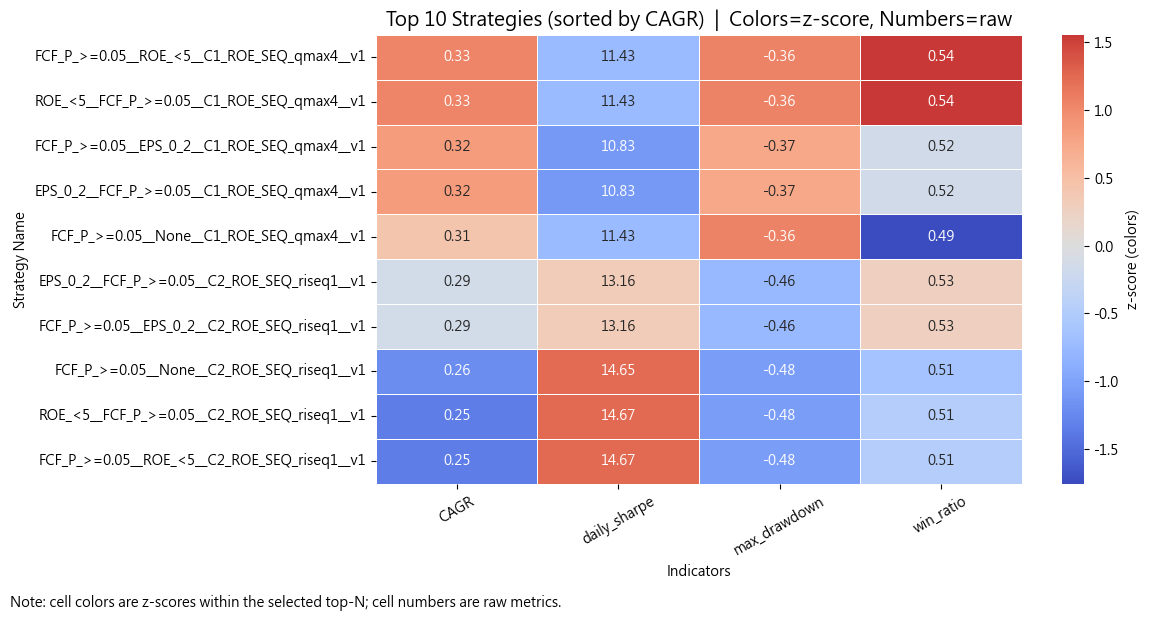

In [18]:
print("\n=== 各 JSON 前幾名合併後之 Heatmap 比較 ===")
rg.plot_group_stats_heatmap(
    combined_top,
    sort_by=pick_spec.sort_by,
    top_n=10,
    indicators=None,
    figsize=(12, 6),
    normalize=True
)

### 圖 B.2　單一策略資產曲線與年度報酬分解

以 CAGR 排名第一的策略為例，展開其完整績效細節：資產淨值曲線、回檔走勢、月報酬分布、持股數量變化與年度報酬分解。

這張圖可用來觀察：績效在時間軸上的分布是否均勻、累積報酬的階段性變化，以及各年度報酬的高低落差與風險樣態。

這一步要回答的是：當系統定位出一組高排名策略後，能否進一步揭露其報酬的時間結構與風險樣態，作為後續往個股層級拆解獲利來源的起點，而不只是給出一個總結數字。

In [19]:
# 取 CAGR 排名第一的策略，展開其完整績效報表（以 rep.display() 呈現）
_df_cagr = df.copy()
_df_cagr["CAGR"] = pd.to_numeric(_df_cagr["CAGR"], errors="coerce")
top1_name = _df_cagr.sort_values("CAGR", ascending=False).iloc[0]["strategy_dir"]

_label = list(report_collections.keys())[0]
top1_rep = report_collections[_label].reports.get(top1_name)
if top1_rep is None:
    # 後備：直接從 4-2 合併後的 Top 集合取第一名
    top1_name, top1_rep = next(iter(combined_top.reports.items()))

print("CAGR 第一名策略：", top1_name)
top1_rep.display()
print(top1_rep.get_stats())

CAGR 第一名策略： FCF_P_>=0.05__ROE_<5__C1_ROE_SEQ_qmax4__v1


,annualized_rate_of_return,sharpe,max_drawdown,win_ratio
,32.65%,11.43,-35.68%,54.43%


,entry_date,exit_date,entry_sig_date,exit_sig_date,position,period,entry_index,exit_index,return,mae,gmfe,bmfe,mdd,pdays,weight,next_weights
stock_id,,,,,,,,,,,,,,,,
1259,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.011670,-0.021563,1.752022e-02,1.078167e-02,-0.032000,35.0,0.0,0.0
1416,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.091711,-0.004878,1.073171e-01,9.756098e-03,-0.014493,42.0,0.0,0.0
1527,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.030001,-0.015365,3.585147e-02,2.176697e-02,-0.036341,48.0,0.0,0.0
1530,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.051006,-0.013378,5.685619e-02,6.688963e-03,-0.019934,34.0,0.0,0.0
1537,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,-0.002062,-0.018939,1.136364e-02,3.787879e-03,-0.022642,12.0,0.0,0.0
1618,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.162825,-0.010040,1.887550e-01,1.887550e-01,-0.167230,59.0,0.0,0.0
1702,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.050754,-0.004193,5.660377e-02,2.096436e-03,-0.035857,57.0,0.0,0.0
2303,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.066360,-0.037199,1.006565e-01,3.282276e-02,-0.067797,49.0,0.0,0.0
2363,2023-09-01,2023-12-01,2023-08-31,2023-11-30,0.029412,62,5860,5922,0.327483,-0.044444,4.916667e-01,1.527778e-02,-0.178771,53.0,0.0,0.0


{'CAGR': 0.32654486799495563, 'daily_sharpe': 11.43, 'max_drawdown': -0.3567662972970673, 'avg_drawdown': -0.10530188515004216, 'win_ratio': 0.5443478260869565, 'ytd': 0.3628659381678456}


### 圖 B.3　單一策略年度股票貢獻度分布

將 CAGR 第一名策略各年度的獲利拆解至個股層級，呈現每年度貢獻度最高的前 10 檔個股與其餘個股的加總貢獻。

這張圖可用來觀察：各年度的主要貢獻個股是否固定、單一個股在高報酬年度是否占壓倒性比例，以及整體獲利是由多檔個股分別累積、還是由少數標的驅動。

這一步要回答的是：高排名策略的獲利是否健康地分散在多檔標的，初步排除單一策略層級的個股集中疑慮。

> 註：`compute_annual_contribution` 需要 `price:close`，故先以 `get_data.Data` 載入市場資料。

In [20]:
# 載入市場資料（供年度貢獻度分解使用：compute_annual_contribution 需要 price:close）
from get_data import Data
data = Data()
data.get("price:close")

company_symbol,1101,1102,1103,1104,1108,1109,1110,1201,1203,1210,...,9944,9945,9946,9949,9950,9951,9955,9958,9960,9962
date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,7.5067,5.3558,5.5019,2.6105,5.4752,5.4740,6.2886,6.5692,6.4118,1.7259,...,NaN,1.5950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,7.7020,5.7189,5.5304,2.6507,5.6920,5.5840,6.2573,7.0125,6.4685,1.7978,...,NaN,1.6852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,7.3766,5.7734,5.7584,2.7042,5.6920,5.7159,6.4450,7.4961,6.6387,1.8377,...,NaN,1.7605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,7.3549,5.7734,5.8155,2.6908,5.6920,5.7379,6.4450,8.0200,6.6955,1.8457,...,NaN,1.7605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-10,7.5935,5.8097,5.9580,2.6908,5.6107,5.6719,6.3512,8.5439,6.8941,1.8537,...,NaN,1.7605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,34.3500,40.3000,18.8000,29.3500,15.7000,18.1500,18.7500,19.0000,53.2000,57.7000,...,20.15,36.2500,20.15,17.60,22.8,75.3,24.20,168.0,27.30,18.45
2023-12-26,34.5000,40.5500,18.8000,29.4000,15.7500,18.1000,18.5500,19.0500,53.5000,57.4000,...,20.20,36.4000,20.15,18.05,22.6,76.8,24.20,167.0,27.25,18.30
2023-12-27,34.6500,40.9000,18.9000,29.5500,15.8000,18.1000,18.7500,19.0500,54.7000,57.3000,...,20.15,36.8000,20.40,17.90,22.4,75.8,24.45,167.0,27.10,18.20


In [21]:
# 對 CAGR 第一名策略執行年度股票貢獻度分解（範圍為單一策略）
figs = {}
strat_name = top1_name
rep = top1_rep

# price:close 的索引可能是 datetime.date（非 DatetimeIndex），
# 先轉成 Timestamp，字串日期切片 start:end 才能運作
_close = data.get("price:close").copy()
_close.index = pd.to_datetime(_close.index)

annual_contrib_df = rg.compute_annual_contribution(
    change_data={'price:close': _close},
    position=rep.position,
    start='2009-03-31',
    end='2024-12-31',
    monthly_shift=1,
    close_key='price:close',
)
figs[strat_name] = rg.plot_annual_contribution_stacked(
    annual_contrib_df,
    top_N=10,
    title=f'[{strat_name}] 年度股票資金貢獻度分布（Top10 + 其他）'
)
figs[strat_name].show()

### 圖 B.4 ~ 圖 B.9　個股貢獻度與集中度分析

將觀察範圍由單一策略擴大到整個策略集合：取 CAGR 前 25% 與前 50% 兩個集合，統計各策略中貢獻最高個股（Top1）的出現頻率與貢獻占比，並以累積貢獻曲線與 Effective N（HHI 倒數）量化獲利的集中程度。核心問題是：排名前段策略的高報酬究竟來自 F-C-V 架構的篩選能力，還是少數個股在回測期間的極端表現。

下列前置 cell 載入 `stats.parquet` 與各策略的 `trades.parquet`，計算每個策略的個股貢獻與集中度指標。

In [22]:
# ===== 參數設定（集中在這一格調整）=====
from pathlib import Path

# artifacts 根目錄（含 stats.parquet 與各策略資料夾）
ARTIFACTS_DIR = (Path.cwd() / "results_artifacts" / "fcv_experiment_spec").resolve()

# 策略排名依據（預設 'CAGR'；stats.parquet 欄位不同時改成對應欄位）
PRIMARY_METRIC = "CAGR"

# 若要先過濾：最低交易筆數 / 最低樣本數 等（stats 沒有對應欄位時保持 None）
MIN_TRADES = None   # 例如 50
MIN_POS_RATE = None # 例如 0.05

# 取前幾名策略做「單策略細看」圖表（treemap / pareto）
TOP_STRATEGY_DETAIL_N = 10

# 取前幾大個股顯示（Pareto bar / Treemap）
TOP_STOCKS_SHOW = 20

# 分位組：前 25% 與前 50%
TOP_PCTS = [0.25, 0.50]

print("ARTIFACTS_DIR =", ARTIFACTS_DIR)

ARTIFACTS_DIR = D:\研究所\stock_factor_lab-master\stock_factor_lab\code\results_artifacts\fcv_experiment_spec


In [23]:
# ===== 環境與工具函式 =====
import sys
from pathlib import Path

# ===== 重要：確保 Python 能找到本地模組（report.py、io_persistence.py 等）=====
# notebook 在 code/ 目錄中，所以需要把 code/ 和上層 ROOT_DIR 都加入 sys.path
CODE_DIR = Path.cwd().resolve()
ROOT_DIR = CODE_DIR.parent  # 上層目錄（放 report.py 等）

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(f"[INFO] CODE_DIR = {CODE_DIR}")
print(f"[INFO] ROOT_DIR = {ROOT_DIR}")
print(f"[INFO] sys.path 已更新")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 匯入本地模組
from io_persistence import load_strategy_artifacts, load_artifacts_stats

def find_stats_path(root: Path) -> Path | None:
    cand = root / "stats.parquet"
    if cand.exists():
        return cand
    cand = root / "stats.csv"
    if cand.exists():
        return cand
    for p in root.rglob("stats.parquet"):
        return p
    for p in root.rglob("stats.csv"):
        return p
    return None

def list_strategy_dirs(root: Path):
    """以「資料夾底下有 trades/position/stock_data/return_table 任一檔」作為策略資料夾"""
    dirs = []
    for p in root.iterdir():
        if not p.is_dir():
            continue
        if any((p / f"{name}.parquet").exists() or (p / f"{name}.csv").exists()
               for name in ["trades","position","stock_data","return_table"]):
            dirs.append(p)
    return sorted(dirs)

def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")

# ---- 個股貢獻（trade-based）----
def stock_contrib_from_trades(trades: pd.DataFrame, method: str = "log"):
    '''
    method:
      - 'log'：以 log(1+r) 做可加總的貢獻分解（較穩定）
      - 'compound'：先對同股 trades 做 (1+r) 累乘，再取 -1 當作同股累積報酬
    回傳：pd.Series(index=stock_id, values=contrib_score)
    '''
    if trades is None or len(trades) == 0:
        return pd.Series(dtype=float)

    if "stock_id" not in trades.columns or "return" not in trades.columns:
        raise ValueError("trades 需要包含欄位：stock_id, return")

    df = trades.copy()
    df["return"] = safe_numeric(df["return"])
    df = df.dropna(subset=["stock_id","return"])

    # return 不能 <= -1，否則 log1p 會炸掉；用 clip 避免極端資料造成中斷
    r = df["return"].clip(lower=-0.999999, upper=10)
    df["_r_clip"] = r

    if method == "compound":
        out = (1 + df["_r_clip"]).groupby(df["stock_id"]).prod() - 1
        out.name = "contrib"
        return out.sort_values(ascending=False)

    # default: 'log' additive
    out = np.log1p(df["_r_clip"]).groupby(df["stock_id"]).sum()
    out.name = "contrib_log"
    return out.sort_values(ascending=False)

def topk_share(contrib: pd.Series, k: int, positive_only: bool = True) -> float:
    if contrib is None or len(contrib) == 0:
        return np.nan
    x = contrib.copy()
    if positive_only:
        x = x.clip(lower=0)
    tot = x.sum()
    if tot <= 0:
        return np.nan
    return float(x.nlargest(k).sum() / tot)

def hhi(contrib: pd.Series, positive_only: bool = True) -> float:
    if contrib is None or len(contrib) == 0:
        return np.nan
    x = contrib.copy()
    if positive_only:
        x = x.clip(lower=0)
    tot = x.sum()
    if tot <= 0:
        return np.nan
    w = x / tot
    return float((w**2).sum())

def gini(contrib: pd.Series, positive_only: bool = True) -> float:
    '''Gini over non-negative values. 0 = 均勻、1 = 極端集中'''
    if contrib is None or len(contrib) == 0:
        return np.nan
    x = contrib.copy()
    if positive_only:
        x = x.clip(lower=0)
    x = x.dropna().values
    if len(x) == 0:
        return np.nan
    if np.allclose(x.sum(), 0):
        return np.nan
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return float((n + 1 - 2 * (cumx.sum() / cumx[-1])) / n)

def effective_n_from_hhi(hhi_value: float) -> float:
    if hhi_value is None or np.isnan(hhi_value) or hhi_value <= 0:
        return np.nan
    return float(1.0 / hhi_value)

def cumulative_share_curve(contrib: pd.Series, positive_only: bool = True, max_k: int = 50):
    '''回傳：k(1..max_k) 對應的累積占比（排序後）'''
    if contrib is None or len(contrib) == 0:
        return np.full(max_k, np.nan)
    x = contrib.copy()
    if positive_only:
        x = x.clip(lower=0)
    x = x[x > 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.full(max_k, np.nan)
    tot = x.sum()
    vals = (x.values.cumsum() / tot)
    vals = np.pad(vals[:max_k], (0, max(0, max_k-len(vals))), constant_values=np.nan)
    return vals

print("Ready.")


[INFO] CODE_DIR = D:\研究所\stock_factor_lab-master\stock_factor_lab\code
[INFO] ROOT_DIR = D:\研究所\stock_factor_lab-master\stock_factor_lab
[INFO] sys.path 已更新
Ready.


In [24]:
# ===== 2) 載入 stats 與策略列表 =====
stats_path = find_stats_path(ARTIFACTS_DIR)
if stats_path is None:
    raise FileNotFoundError("找不到 stats.parquet / stats.csv，請確認 ARTIFACTS_DIR 設定正確。")

stats = load_artifacts_stats(stats_path)

# stats 可能沒有 strategy_dir 欄位；常見狀況是 index 或某欄位就是資料夾名
if "strategy_dir" not in stats.columns:
    text_cols = [c for c in stats.columns if stats[c].dtype == "object"]
    if len(text_cols) > 0:
        stats = stats.rename(columns={text_cols[0]: "strategy_dir"})
    else:
        stats = stats.reset_index().rename(columns={"index": "strategy_dir"})

if PRIMARY_METRIC not in stats.columns:
    raise KeyError(f"stats 裡找不到欄位 {PRIMARY_METRIC}，可先 print(stats.columns) 看看有哪些欄位。")

stats[PRIMARY_METRIC] = pd.to_numeric(stats[PRIMARY_METRIC], errors="coerce")
stats = stats.dropna(subset=[PRIMARY_METRIC])

# 可選：套用過濾條件（若 stats 有對應欄位才會生效）
if MIN_TRADES is not None and "trade_count" in stats.columns:
    stats = stats[stats["trade_count"] >= MIN_TRADES]
if MIN_POS_RATE is not None and "pos_rate" in stats.columns:
    stats = stats[stats["pos_rate"] >= MIN_POS_RATE]

strategy_dirs = list_strategy_dirs(ARTIFACTS_DIR)
strategy_dir_map = {p.name: p for p in strategy_dirs}
stats = stats[stats["strategy_dir"].isin(strategy_dir_map.keys())].copy()

print("stats rows =", len(stats))
print("strategy dirs =", len(strategy_dirs))
stats.sort_values(PRIMARY_METRIC, ascending=False).head(10)

stats rows = 266
strategy dirs = 1118


,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,strategy_dir
237,0.220851,14.78,-0.559800,-0.078818,0.524443,0.338380,EPS_0_2__None__C1_ROE_SEQ_qmax4__v1
370,0.199542,17.72,-0.669828,-0.100392,0.529670,0.290177,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v1
371,0.199542,17.72,-0.669828,-0.100392,0.529670,0.290177,FCF_P_0_0.05__EPS_0_2__C1_ROE_SEQ_qmax4__v1
145,0.196111,18.51,-0.597530,-0.094569,0.517705,0.303500,EPS_0_2__None__C2_ROE_SEQ_riseq1__v1
331,0.184376,18.46,-0.647397,-0.100131,0.525434,0.395154,FCF_P_0_0.05__None__C1_ROE_SEQ_qmax4__v1
147,0.181087,18.44,-0.579812,-0.082109,0.520336,0.334892,EPS_0_2__None__C6_EPS_QOQ_yoy__v1
25,0.173084,16.91,-0.531520,-0.073266,0.478542,0.358336,EPS_0_2__None__C6_EPS_QOQ_yoy__v0
150,0.168719,18.24,-0.575237,-0.084392,0.516791,0.352794,EPS_0_2__None__C3_ROE_SEQ_yoy__v1
26,0.168179,16.84,-0.529259,-0.072542,0.470861,0.336041,EPS_0_2__None__C3_ROE_SEQ_yoy__v0
259,0.162227,19.28,-0.555633,-0.094289,0.522551,0.381150,FCF_P_0_0.05__EPS_0_2__C3_ROE_SEQ_yoy__v1


In [25]:
# ===== 3) 取 Top 25% / Top 50% 策略清單 =====
stats_sorted = stats.sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)

def select_top_pct(df: pd.DataFrame, pct: float):
    n = max(1, int(np.ceil(len(df) * pct)))
    return df.iloc[:n].copy()

top_groups = {pct: select_top_pct(stats_sorted, pct) for pct in TOP_PCTS}
{pct: len(df) for pct, df in top_groups.items()}

{0.25: 67, 0.5: 133}

In [26]:
# ===== 4) 計算每個策略的「個股貢獻／集中度」指標 =====
def compute_strategy_stock_metrics(strategy_name: str, method: str = "log", max_curve_k: int = 50):
    strat_dir = strategy_dir_map[strategy_name]
    # 直接讀取 parquet，而不用 load_strategy_artifacts
    trades_path = strat_dir / "trades.parquet"
    if not trades_path.exists():
        return {"strategy_dir": strategy_name, "n_stocks": 0}, np.full(max_curve_k, np.nan)
    trades = pd.read_parquet(trades_path)
    contrib = stock_contrib_from_trades(trades, method=method)

    row = {
        "strategy_dir": strategy_name,
        "contrib_method": method,
        "n_stocks": int(contrib.shape[0]),
        "n_pos_stocks": int((contrib.clip(lower=0) > 0).sum()) if len(contrib) else 0,
        "top1_share": topk_share(contrib, 1, positive_only=True),
        "top3_share": topk_share(contrib, 3, positive_only=True),
        "top5_share": topk_share(contrib, 5, positive_only=True),
        "top10_share": topk_share(contrib, 10, positive_only=True),
        "hhi": hhi(contrib, positive_only=True),
        "gini": gini(contrib, positive_only=True),
    }
    row["eff_n"] = effective_n_from_hhi(row["hhi"])

    if len(contrib):
        row["top1_stock"] = contrib.index[0]
        row["top1_contrib"] = float(contrib.iloc[0])
    else:
        row["top1_stock"] = None
        row["top1_contrib"] = np.nan

    curve = cumulative_share_curve(contrib, positive_only=True, max_k=max_curve_k)
    return row, curve

def build_group_metrics(df_group: pd.DataFrame, method="log", max_curve_k=50):
    rows = []
    curves = []
    for s in df_group["strategy_dir"]:
        r, c = compute_strategy_stock_metrics(s, method=method, max_curve_k=max_curve_k)
        rows.append(r)
        curves.append(c)
    out_df = pd.DataFrame(rows)
    curves = np.vstack(curves) if len(curves) else np.empty((0, max_curve_k))
    return out_df, curves

group_results = {}
for pct, df_g in top_groups.items():
    mdf, curves = build_group_metrics(df_g, method="log", max_curve_k=TOP_STOCKS_SHOW)
    mdf["group"] = f"Top {int(pct*100)}%"
    group_results[pct] = {"metrics": mdf, "curves": curves}

metrics_all = pd.concat([group_results[p]["metrics"] for p in TOP_PCTS], ignore_index=True)
metrics_all.head()

,strategy_dir,contrib_method,n_stocks,n_pos_stocks,top1_share,top3_share,top5_share,top10_share,hhi,gini,eff_n,top1_stock,top1_contrib,group
0,EPS_0_2__None__C1_ROE_SEQ_qmax4__v1,log,1241,687,0.012307,0.027799,0.041834,0.072037,0.002816,0.716960,355.064714,3205,2.262396,Top 25%
1,EPS_0_2__FCF_P_0_0.05__C1_ROE_SEQ_qmax4__v1,log,851,448,0.017204,0.041826,0.064316,0.111181,0.004659,0.744495,214.654229,2481,1.548002,Top 25%
2,FCF_P_0_0.05__EPS_0_2__C1_ROE_SEQ_qmax4__v1,log,851,448,0.017204,0.041826,0.064316,0.111181,0.004659,0.744495,214.654229,2481,1.548002,Top 25%
3,EPS_0_2__None__C2_ROE_SEQ_riseq1__v1,log,1493,849,0.006576,0.017797,0.028608,0.053980,0.002204,0.706158,453.802453,3205,1.961295,Top 25%
4,FCF_P_0_0.05__None__C1_ROE_SEQ_qmax4__v1,log,1011,531,0.014045,0.037677,0.059381,0.103211,0.004016,0.746411,249.025939,2481,1.548002,Top 25%


In [27]:
# ===== 5) 圖表 1：Top-k 貢獻占比（直觀看集中度）=====
m = metrics_all.copy()

fig = px.violin(
    m.dropna(subset=["top1_share"]),
    x="group", y="top1_share",
    box=True, points="all",
    title="Top1 個股獲利占比（positive contribution share）"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

fig = px.violin(
    m.dropna(subset=["top5_share"]),
    x="group", y="top5_share",
    box=True, points="all",
    title="Top5 個股獲利占比（positive contribution share）"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

fig = px.violin(
    m.dropna(subset=["top10_share"]),
    x="group", y="top10_share",
    box=True, points="all",
    title="Top10 個股獲利占比（positive contribution share）"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

**圖 B.4、圖 B.5（CAGR 前 25%）與圖 B.6、圖 B.7（CAGR 前 50%）**：各集合中 Top1 貢獻個股的出現頻率（前 20 名）與其平均貢獻占比。

這組圖可用來觀察：是否有少數個股壟斷多數策略的 Top1、Top1 平均占比的高低，以及由前 25% 擴大到前 50% 後，中段策略對特定個股的依賴是否加深。

In [28]:
# ===== 8) 圖表 4：Top1 個股是誰？（頻率 + 平均占比）=====
def top1_frequency_table(metrics_df: pd.DataFrame, top_n=20):
    df = metrics_df.dropna(subset=["top1_stock"]).copy()
    freq = df["top1_stock"].value_counts().rename("freq")
    avg_share = df.groupby("top1_stock")["top1_share"].mean().rename("avg_top1_share")
    out = pd.concat([freq, avg_share], axis=1).fillna(0).sort_values("freq", ascending=False).head(top_n).reset_index()
    # reset_index() 後，index 欄位會自動命名為 "top1_stock"，需要重命名為 "stock_id"
    out = out.rename(columns={"top1_stock": "stock_id"})
    return out

for pct in TOP_PCTS:
    label = f"Top {int(pct*100)}%"
    t = top1_frequency_table(group_results[pct]["metrics"], top_n=TOP_STOCKS_SHOW)

    fig = px.bar(t, x="stock_id", y="freq", title=f"{label}：Top1 貢獻個股出現頻率（Top {TOP_STOCKS_SHOW}）")
    fig.show()

    fig = px.bar(t, x="stock_id", y="avg_top1_share", title=f"{label}：Top1 占比平均（越高越集中）")
    fig.update_yaxes(tickformat=".0%")
    fig.show()


**圖 B.8　累積獲利貢獻曲線**：依個股貢獻度由高至低累加至前 20 檔，分別繪製前 25% 與前 50% 集合的中位數、第 25 與第 75 百分位曲線。

這張圖可用來觀察：三條百分位曲線的緊密程度與斜率、帶寬大小，以及前段少數個股是否即貢獻大部分獲利（曲線是否在前幾檔陡升），藉此比較兩個集合的獲利集中程度。

In [29]:
# ===== 7) 圖表 3：累積貢獻曲線（Pareto/Lorenz-like）=====
def summarize_curves(curves: np.ndarray):
    df = pd.DataFrame(curves)
    return {
        "mean": df.mean(axis=0).values,
        "p25": df.quantile(0.25, axis=0).values,
        "p50": df.quantile(0.50, axis=0).values,
        "p75": df.quantile(0.75, axis=0).values,
    }

fig = go.Figure()
x = np.arange(1, TOP_STOCKS_SHOW + 1)

for pct in TOP_PCTS:
    label = f"Top {int(pct*100)}%"
    curves = group_results[pct]["curves"]
    s = summarize_curves(curves)
    fig.add_trace(go.Scatter(x=x, y=s["p50"], mode="lines", name=f"{label} median"))
    fig.add_trace(go.Scatter(x=x, y=s["p25"], mode="lines", name=f"{label} p25", line=dict(dash="dot")))
    fig.add_trace(go.Scatter(x=x, y=s["p75"], mode="lines", name=f"{label} p75", line=dict(dash="dot")))

fig.update_layout(
    title=f"累積獲利貢獻曲線（依個股貢獻排序）— k=1..{TOP_STOCKS_SHOW}",
    xaxis_title="前 k 名個股",
    yaxis_title="累積占比（正向貢獻）",
)
fig.update_yaxes(tickformat=".0%")
fig.show()

**圖 B.9　Effective N 盒鬚圖**：以 Effective N（HHI 倒數，越低代表越集中）比較兩個集合。

這張圖可用來觀察：兩個集合的中位數、下四分位數與低值離群點分布，藉此比較前 25% 與前 50% 策略在獲利分散性與穩健性上的差異。

In [30]:
# ===== 6) 圖表 2：集中度指標（HHI / Effective N / Gini）=====
m = metrics_all.copy()

fig = px.box(m.dropna(subset=["hhi"]), x="group", y="hhi", points="all", title="HHI（越高越集中）")
fig.show()

fig = px.box(m.dropna(subset=["eff_n"]), x="group", y="eff_n", points="all", title="Effective N = 1/HHI（越低越集中）")
fig.show()

fig = px.box(m.dropna(subset=["gini"]), x="group", y="gini", points="all", title="Gini（越高越不均）")
fig.show()

## C. 體質構面

確認整體架構具備篩選能力且獲利分散後，進一步拆解體質構面，回應兩個問題：單層篩選（僅 F[1]）是否已能區辨各區間的優劣？加入第二層因子 F[2] 後，績效分布是否出現有意義的收斂，使雙層篩選取得實證支持？

### 圖 C.1　單層體質因子 CAGR 分布盒鬚圖（F[2]=None，涵蓋所有 C/V）

只看 F[2]=None 的策略、不限制 C 與 V，依 F[1] 分組檢視 CAGR 分布，各區間依中位數排序。

這張圖可用來觀察：排名前段與後段 F[1] 區間之間中位數是否存在明確落差（單層體質因子是否已具方向性區辨能力），以及同一區間內四分位距的寬窄（單層篩選是否仍混雜績效差異大的組合、需第二層因子收斂）。

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\F_mean_CAGR_by_F1_F2None_allCV.png


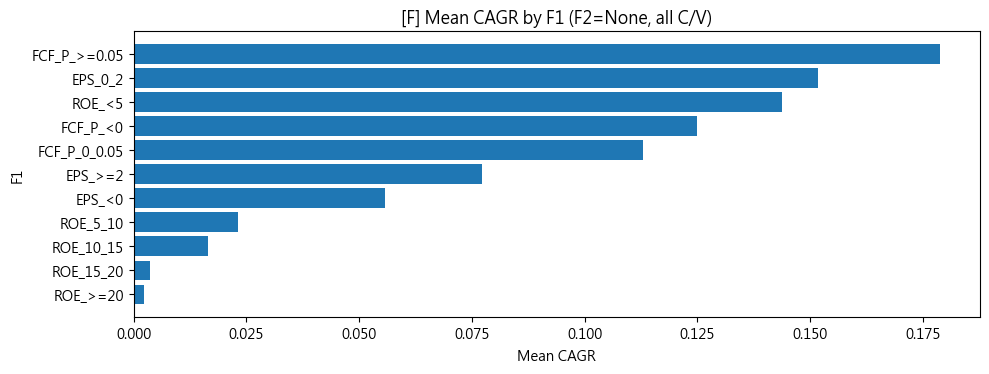

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\F_box_CAGR_by_F1_F2None_allCV.png


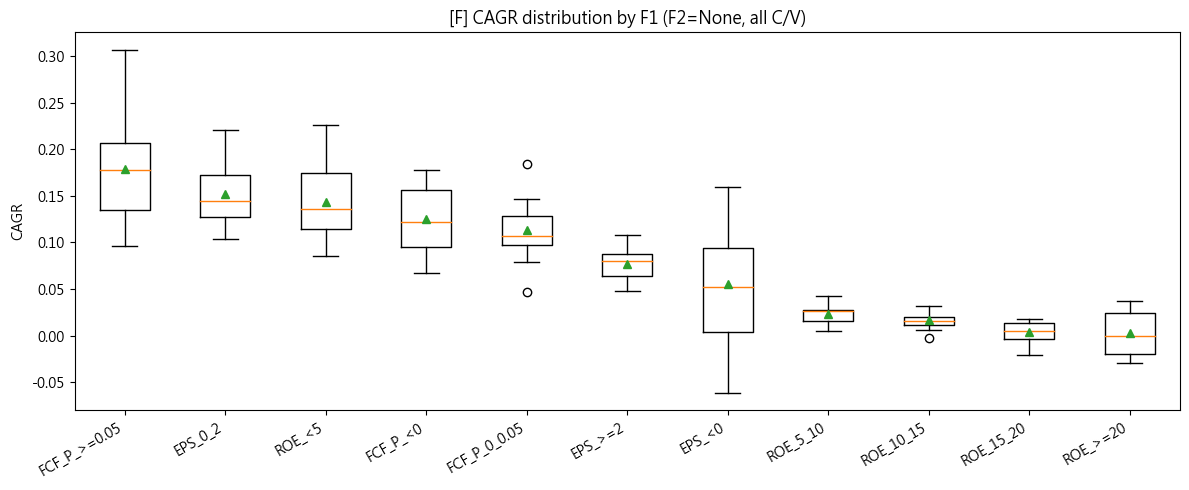

F2=None strategies: 154
F1
ROE_<5          14
EPS_0_2         14
FCF_P_0_0.05    14
FCF_P_<0        14
FCF_P_>=0.05    14
EPS_<0          14
EPS_>=2         14
ROE_5_10        14
ROE_10_15       14
ROE_>=20        14
ROE_15_20       14
Name: count, dtype: int64


In [31]:
# ------------------------------------------------------------
# 只分析「F2=None」的策略，且 C/V 不設限；按 F1 分組取平均
# ------------------------------------------------------------
metric = PRIMARY_METRIC  # 指定使用 CAGR（或其他）

# 1) 篩出 F2 == None / "None" 的策略（避免 query 對 isnull 的相容性問題）
if "F2" not in df_scored.columns:
    raise KeyError("df_scored 缺少欄位 'F2'，無法篩選 F2=None 策略。")

f2 = df_scored["F2"]
mask_f2_none = f2.isna() | (f2.astype(str).str.strip().str.lower().isin(["none", "nan", "null", ""]))

df_f2none = df_scored.loc[mask_f2_none].copy()

# 2) 依 F1 分組，對所有符合策略（C/V 不限）取平均並畫長條圖
if "F1" not in df_f2none.columns:
    raise KeyError("df_scored 缺少欄位 'F1'，無法以 F1 分組。")

agg_F1_allCV = plot_bar_mean(
    df_f2none,
    group_col="F1",
    metric=metric,
    filter_expr=None,  # 不設限 C/V
    top_k=20,
    title=f"[F] Mean {metric} by F1 (F2=None, all C/V)",
    fname=f"F_mean_{metric}_by_F1_F2None_allCV"
)

# 3) （可選）如要保留「分布」觀點，再畫箱型圖（同樣不設限 C/V）
summ_F1_allCV = plot_box_by_group(
    df_f2none,
    group_col="F1",
    metric=metric,
    filter_expr=None,
    top_k=12,
    title=f"[F] {metric} distribution by F1 (F2=None, all C/V)",
    fname=f"F_box_{metric}_by_F1_F2None_allCV"
)

# 4) （可選）快速檢查：看看 F2=None 到底剩多少筆、F1 有哪些
print("F2=None strategies:", len(df_f2none))
print(df_f2none["F1"].value_counts().head(20))


### 圖 C.2　F[1] × F[2] 雙層體質因子平均 CAGR 熱力圖（C=None，V=V0）

固定不套用 C、估值固定 V0，以隔離體質構面本身的效果，呈現 F[1]×F[2] 交叉組合的平均 CAGR。

這張圖可用來觀察：同一 F[1] 搭配不同 F[2] 時平均 CAGR 的變動幅度（F[2] 是否具實質影響而非重複篩選），以及色階高值端是否由兩個各自表現良好的因子交叉構成（因子間是否為簡單加法關係，「強強組合」是否必然最佳）。

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\F_heatmap_F1xF2_mean_CAGR_CNone_Vv0.png


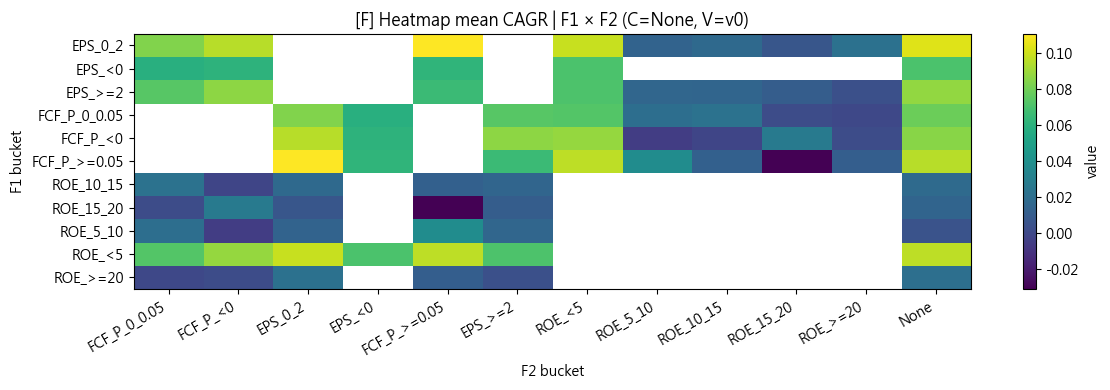

F2,FCF_P_0_0.05,FCF_P_<0,EPS_0_2,EPS_<0,FCF_P_>=0.05,EPS_>=2,ROE_<5,ROE_5_10,ROE_10_15,ROE_15_20,ROE_>=20,None
F1,,,,,,,,,,,,
EPS_0_2,0.083841,0.095233,NaN,NaN,0.110693,NaN,0.098728,0.014387,0.017376,0.007176,0.022147,0.103986
EPS_<0,0.058246,0.060589,NaN,NaN,0.061947,NaN,0.070628,NaN,NaN,NaN,NaN,0.070738
EPS_>=2,0.073770,0.086803,NaN,NaN,0.065588,NaN,0.071265,0.016072,0.015461,0.010837,0.003722,0.087710
FCF_P_0_0.05,NaN,NaN,0.083841,0.058246,NaN,0.073770,0.072905,0.020114,0.022357,0.001924,-0.000181,0.079063
FCF_P_<0,NaN,NaN,0.095233,0.060589,NaN,0.086803,0.088236,-0.004916,-0.001172,0.027807,0.002054,0.085636
FCF_P_>=0.05,NaN,NaN,0.110693,0.061947,NaN,0.065588,0.096547,0.038263,0.012834,-0.030741,0.011369,0.095696
ROE_10_15,0.022357,-0.001172,0.017376,NaN,0.012834,0.015461,NaN,NaN,NaN,NaN,NaN,0.018083
ROE_15_20,0.001924,0.027807,0.007176,NaN,-0.030741,0.010837,NaN,NaN,NaN,NaN,NaN,0.015060
ROE_5_10,0.020114,-0.004916,0.014387,NaN,0.038263,0.016072,NaN,NaN,NaN,NaN,NaN,0.005314


In [32]:
# ------------------------------------------------------------
# F[1] × F[2] 雙層體質因子平均 CAGR 熱力圖（C=None, V=baseline）
# 僅計算 C=None、V=baseline 下的 F1×F2 平均 CAGR（不含其他分組）
# ------------------------------------------------------------
metric = PRIMARY_METRIC
BASE_FILTER = f'V == "{PLOT_V}"'
BASELINE_FILTER = BASE_FILTER + ' and C == "None"'

tmp = df_scored.copy()
tmp[metric] = _to_num(tmp[metric])
tmp = tmp.query(BASELINE_FILTER)

f2_order = sort_buckets(tmp["F2"])
pivot_F = tmp.pivot_table(index="F1", columns="F2", values=metric, aggfunc="mean").reindex(columns=f2_order)

plot_heatmap(
    pivot_F,
    title=f"[F] Heatmap mean {metric} | F1 \u00d7 F2 (C=None, V={PLOT_V})",
    xlabel="F2 bucket",
    ylabel="F1 bucket",
    fname=f"F_heatmap_F1xF2_mean_{metric}_CNone_V{PLOT_V}",
    annotate=False
)

## D. 動態變化構面

動態變化構面（C）能否在不同體質條件下穩定發揮選股效果，是 F-C-V 架構合理性的關鍵檢驗。此處所謂跨體質穩健性，指特定動態因子的相對排序在多種體質固定條件下維持一致的程度；判讀以平均 CAGR 的相對排序為主，不採統計顯著性檢定。分析依四個層次由粗至細推進：不限體質、單層體質固定、雙層體質固定、特定子樹固定。

### 圖 D.1　不限 F 條件下各動態因子之 CAGR 分布盒鬚圖

在 V0、不限體質組合下，比較 C1~C8 八個動態因子的 CAGR 分布。

這張圖可用來觀察：八組盒鬚的中位數是否彼此接近、邊界是否相互重疊。若不控制體質就直接以動態條件分組，體質組合的異質性可能稀釋動態因子的相對效益，這也說明後續分析為何須將體質條件納入控制。

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\C_box_CAGR_by_C_all_Vv0.png


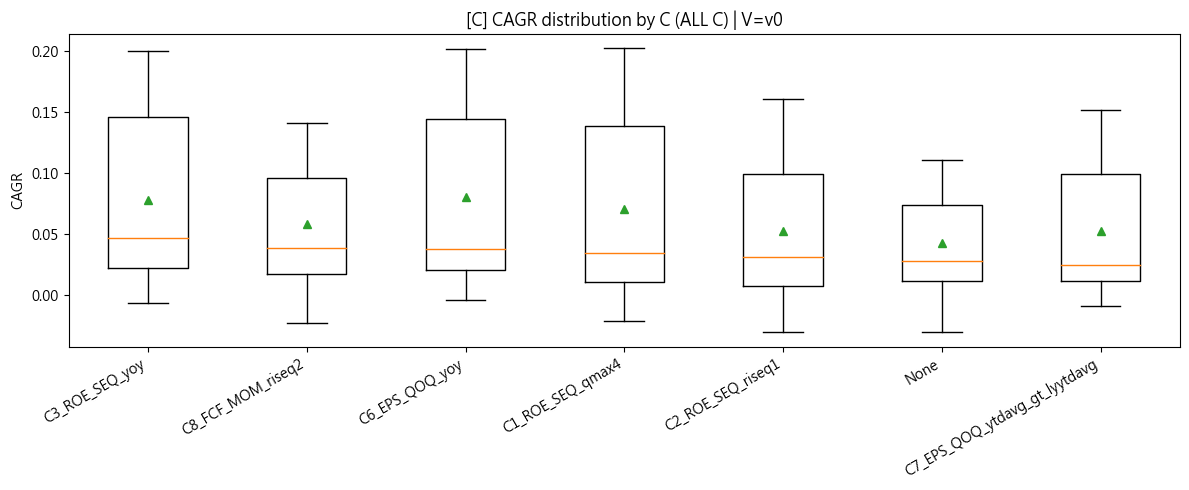

In [33]:
metric = "CAGR"
df_scored[metric] = _to_num(df_scored[metric])

# 全部 C 類別數量
nC = df_scored.query('V=="v0"')["C"].nunique()

summ_C_all = plot_box_by_group(
    df_scored,
    group_col="C",
    metric=metric,
    filter_expr='V == "v0"',
    top_k=nC,  # 用全部類別數取代 10
    title=f"[C] {metric} distribution by C (ALL C) | V=v0",
    fname=f"C_box_{metric}_by_C_all_Vv0"
)


### 圖 D.2　單層體質因子組合下各動態因子之平均年化報酬率

改以單層體質因子（僅固定 F[1] 或僅固定 F[2] 的單一區間）為固定條件，檢視動態因子的相對表現。本圖以折線呈現：橫軸為各動態因子（C 值），每一條折線對應一個體質 bucket（F bucket），縱軸為平均 CAGR。

這張圖可用來觀察：控制體質後，不同動態因子的相對高低是否出現區隔，以及哪些動態因子在多數體質固定條件下穩定落於較高位置，藉此支持「先固定體質、再評估動態」的分析順序。

> 軸向說明：本圖橫軸為動態因子（C 值），每條折線對應一個體質 bucket（F bucket），縱軸為平均 CAGR。

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\C_mean_CAGR_by_C_Vv0.png


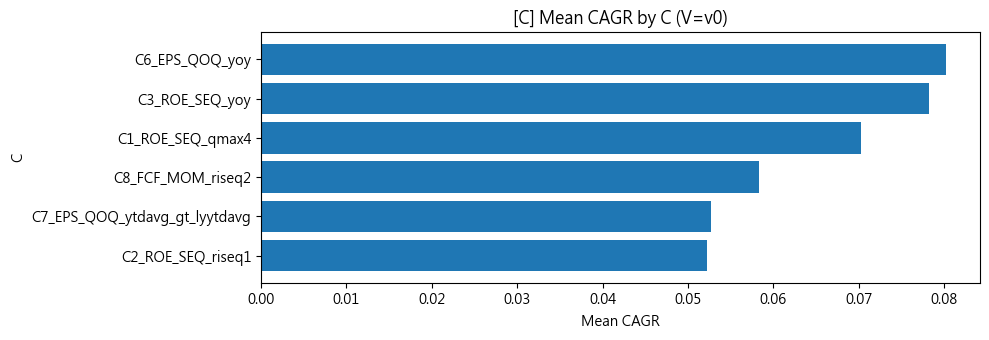

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\C_trend_mean_CAGR_across_F2_topC_Vv0.png


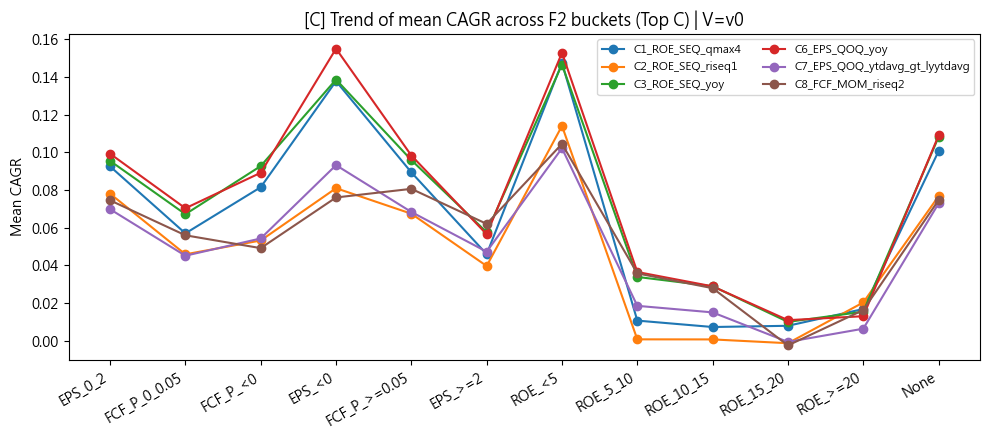

In [34]:
# ------------------------------------------------------------
# C（動態）：各 C 平均 CAGR（固定 V） + Top C 在不同 F2 bucket 的趨勢
# 軸向：x = F2 bucket、每條線 = C 值（與來源 v3 cell 32 (B) 相同）
# ------------------------------------------------------------
metric = PRIMARY_METRIC  # CAGR
BASE_FILTER = f'V == "{PLOT_V}"'

# (A) 平均比較：各 C 的 mean CAGR（固定 V）——用以取得 agg_C 排序
agg_C = plot_bar_mean(
    df_scored.query('C != "None"'), "C", metric,
    filter_expr=BASE_FILTER,
    top_k=20,
    title=f"[C] Mean {metric} by C (V={PLOT_V})",
    fname=f"C_mean_{metric}_by_C_V{PLOT_V}"
)

# (B) 趨勢：Top C 在不同 F2 bucket 的 mean CAGR（固定 V）
tmp = df_scored.copy()
tmp[metric] = _to_num(tmp[metric])
tmp = tmp.query(BASE_FILTER)

f2_order = sort_buckets(tmp["F2"])
topC = agg_C["C"].astype(str).head(8).tolist()  # 取前 8 個避免太擠
trend = tmp[tmp["C"].isin(topC)].pivot_table(index="F2", columns="C", values=metric, aggfunc="mean").reindex(index=f2_order)

fig = plt.figure(figsize=(10, 4.5))
for c in trend.columns:                       # 每條線 = C 值
    plt.plot(range(len(trend.index)), trend[c].values, marker="o", label=str(c))
plt.xticks(range(len(trend.index)), trend.index.astype(str), rotation=30, ha="right")  # x 軸 = F2 bucket
plt.ylabel(f"Mean {metric}")
plt.title(f"[C] Trend of mean {metric} across F2 buckets (Top C) | V={PLOT_V}")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
save_fig(fig, f"C_trend_mean_{metric}_across_F2_topC_V{PLOT_V}")
plt.show()

### 圖 D.3　F[1] × F[2] 雙層體質因子組合下各動態因子之平均年化報酬率熱力圖

把體質條件擴展至 F[1]×F[2] 雙層組合，呈現每一個雙層組合在各動態因子下的平均 CAGR。

這張圖可用來觀察：色階高值是否集中於特定區塊（動態因子的效益是否具條件性），以及同一動態因子在不同體質背景下表現是否有別，藉此判斷動態因子是否需於特定體質背景下才能完整顯現貢獻。

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\FC_heatmap_Fcombo_x_C_mean_CAGR_annotated.png


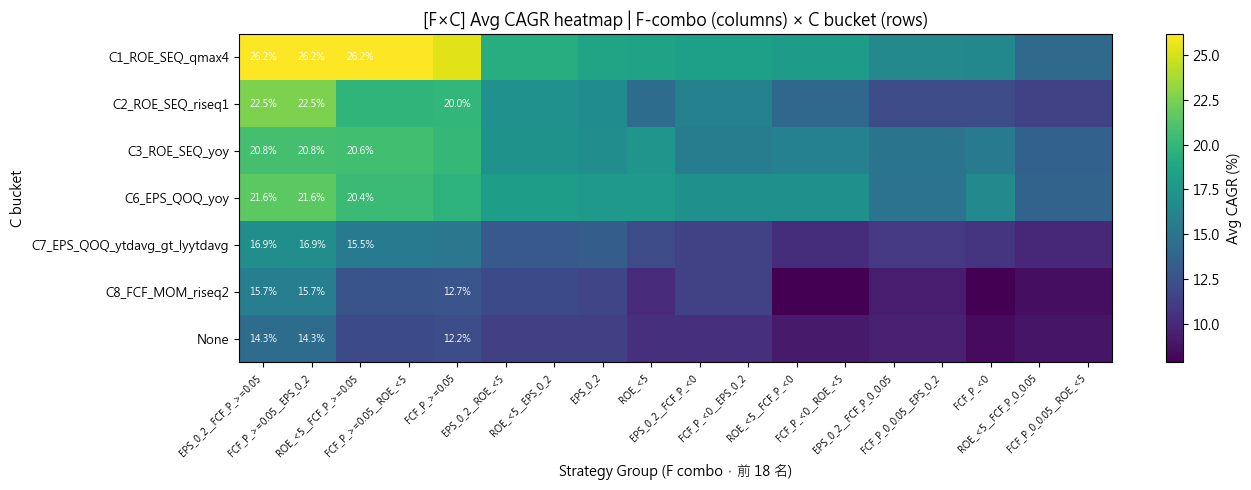

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) 組出「財務體質因子組合」(x 軸)
# -----------------------------
def build_f_combo(df, f_cols=("F1", "F2"), out_col="F_combo"):
    tmp = df.copy()
    for c in f_cols:
        if c not in tmp.columns:
            raise KeyError(f"df_scored 缺少欄位 {c}，無法組 F_combo")
        tmp[c] = tmp[c].astype(str).fillna("None")

    # 把 None/NaN 清掉後再串起來（避免出現 'None__ROE_10_15' 這種醜字）
    def _join_row(row):
        parts = []
        for c in f_cols:
            v = str(row[c]).strip()
            if v.lower() not in ("none", "nan", "null", ""):
                parts.append(v)
        return "__".join(parts) if parts else "None"

    tmp[out_col] = tmp.apply(_join_row, axis=1)
    return tmp


# -----------------------------
# 2) 画「帶數字標註」的 heatmap（百分比）
# -----------------------------
def plot_annotated_heatmap_percent(pivot_df, title, xlabel, ylabel, fname=None,
                                  value_is_ratio=True,  # True: 0.154 -> 15.4%
                                  fmt="%.2f%%",
                                  figsize=(12, 4),
                                  rotate_xticks=45):
    # 轉成 numpy matrix
    data = pivot_df.values.astype(float)

    # 0.154 -> 15.4
    if value_is_ratio:
        plot_data = data * 100.0
    else:
        plot_data = data

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(plot_data, aspect="auto")

    # ticks / labels
    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns.tolist())
    ax.set_yticklabels(pivot_df.index.tolist())
    plt.setp(ax.get_xticklabels(), rotation=rotate_xticks, ha="right")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Avg CAGR (%)")  # 色軸標示

    # annotate each cell (跳過 NaN)
    for i in range(plot_data.shape[0]):
        for j in range(plot_data.shape[1]):
            v = plot_data[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt % v, ha="center", va="center", fontsize=9)

    fig.tight_layout()
    if fname is not None:
        # 使用既有的 save_fig（若存在）
        try:
            save_fig(fig, fname)
        except Exception:
            pass
    plt.show()


# -----------------------------
# 3) 產出「F組合 × C區間」平均 CAGR 熱力圖
# -----------------------------
metric = "CAGR"  # 或 PRIMARY_METRIC
tmp = df_scored.copy()
tmp[metric] = _to_num(tmp[metric])  # 轉數值

# x 軸：財務體質因子組合
tmp = build_f_combo(tmp, f_cols=("F1", "F2"), out_col="F_combo")

# y 軸：C 區間（若有 C_bucket/C_interval，改這行）
y_col = "C"

# pivot：列=C區間、欄=F組合、值=平均CAGR
pivot_Fcombo_C = tmp.pivot_table(
    index=y_col,
    columns="F_combo",
    values=metric,
    aggfunc="mean"
)

# （可選）排序：y 用 sort_buckets，x 用整體平均由高到低
try:
    y_order = sort_buckets(pivot_Fcombo_C.index)
    pivot_Fcombo_C = pivot_Fcombo_C.reindex(index=y_order)
except Exception:
    pass

col_order = pivot_Fcombo_C.mean(axis=0).sort_values(ascending=False).index
pivot_Fcombo_C = pivot_Fcombo_C.reindex(columns=col_order)

# 畫圖：每格顯示「平均 CAGR%」
# 只取平均 CAGR 最高的前 N 個 F_combo 欄位來顯示，避免欄位過多導致標籤與數字重疊
# 注意：pivot_Fcombo_C 維持完整不動（下一張 plot_heatmap_nicer 仍會用到），這裡只取子集顯示
_TOP_N_COLS = 18
_pivot_show = pivot_Fcombo_C.iloc[:, :_TOP_N_COLS]   # 欄位已依 mean 由高至低排序

fig, ax = plt.subplots(figsize=(max(12, 0.75 * _pivot_show.shape[1]), 5))
_data = _pivot_show.values.astype(float) * 100.0     # 0.15 -> 15.0 (%)
im = ax.imshow(_data, aspect="auto", cmap="viridis")

ax.set_xticks(np.arange(_pivot_show.shape[1]))
ax.set_yticks(np.arange(_pivot_show.shape[0]))
ax.set_xticklabels(_pivot_show.columns.tolist(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(_pivot_show.index.tolist(), fontsize=9)
ax.set_xlabel(f"Strategy Group (F combo，前 {_TOP_N_COLS} 名)")
ax.set_ylabel(f"{y_col} bucket")
ax.set_title("[F×C] Avg CAGR heatmap | F-combo (columns) × C bucket (rows)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Avg CAGR (%)")

# 每一列只標出該列數值最大的前 3 格，避免數字整片黏在一起
for i in range(_data.shape[0]):
    row = _data[i, :]
    finite = np.where(np.isfinite(row))[0]
    for j in finite[np.argsort(row[finite])[::-1][:3]]:
        ax.text(j, i, f"{row[j]:.1f}%", ha="center", va="center", fontsize=7, color="white")

fig.tight_layout()
try:
    save_fig(fig, "FC_heatmap_Fcombo_x_C_mean_CAGR_annotated")
except Exception:
    pass
plt.show()


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 把單一條件文字縮短
def _short_factor_label(s: str) -> str:
    s = str(s).strip()
    # 常見因子縮寫/格式調整（可自行加）
    s = s.replace("DEBT_R", "Debt")
    s = s.replace("ROE", "ROE")
    s = s.replace("EPS", "EPS")
    s = s.replace("FCF", "FCF")

    # 區間符號簡化
    s = s.replace("_0_2", " 0–2")
    s = s.replace("_>2", " >2")
    s = s.replace("_>0", " >0")
    s = s.replace("_5_10", " 5–10%")
    s = s.replace("_10_15", " 10–15%")
    s = s.replace("_15_20", " 15–20%")

    # 最後清一下底線
    s = s.replace("_", " ")
    return s

# 2) F combo label：把 "__" 當成 +，並換行
def pretty_combo_label(combo: str, max_parts_per_line=1) -> str:
    parts = [p for p in str(combo).split("__") if p and p.lower() not in ("none", "nan", "null")]
    parts = [_short_factor_label(p) for p in parts]
    if not parts:
        return "None"

    # 每行放 max_parts_per_line 個，換行（預設 1 個一行最清楚）
    lines, buf = [], []
    for p in parts:
        buf.append(p)
        if len(buf) >= max_parts_per_line:
            lines.append(" + ".join(buf))
            buf = []
    if buf:
        lines.append(" + ".join(buf))
    return "\n".join(lines)

# 3) 好看的 heatmap：欄數縮減 + 條件式標註 + 動態尺寸
def plot_heatmap_nicer(
    pivot_df,
    title,
    xlabel="Strategy Group (F combo)",
    ylabel="C bucket",
    fname=None,
    value_is_ratio=True,          # CAGR 若是 0.12 代表 12% -> True
    top_cols=14,                  # 只顯示前 N 欄
    col_rank_by="mean",           # mean / count
    min_count_per_col=None,       # 例如 5：欄位至少要有 5 策略才納入（需先提供 count pivot）
    annotate="topk",              # "all" / "none" / "topk" / "threshold"
    annotate_topk=3,              # 每一列只標前 K
    annotate_threshold=8.0,       # 若 annotate="threshold"，只標 >= 8 (%)
    cmap="viridis",
    base_width=10,
    col_width=0.55,              # 每多一欄增加寬度
    base_height=3.2,
    row_height=0.55,             # 每多一列增加高度
    tick_fontsize=9,
    ann_fontsize=8,
    rotate_xticks=0              # 已換行，通常不用旋轉
):
    df = pivot_df.copy()

    # 只取前 top_cols 欄（用欄平均或有效資料量排序）
    if col_rank_by == "mean":
        col_order = df.mean(axis=0).sort_values(ascending=False).index
    elif col_rank_by == "count":
        col_order = df.count(axis=0).sort_values(ascending=False).index
    else:
        col_order = df.columns

    df = df.reindex(columns=col_order)

    if top_cols is not None and df.shape[1] > top_cols:
        df = df.iloc[:, :top_cols]

    data = df.values.astype(float)
    plot_data = data * 100.0 if value_is_ratio else data

    nrows, ncols = df.shape
    fig_w = max(base_width, base_width + col_width * max(0, ncols - 10))
    fig_h = max(base_height, base_height + row_height * max(0, nrows - 4))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(plot_data, aspect="auto", cmap=cmap)

    # y 軸
    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels(df.index.tolist(), fontsize=tick_fontsize)

    # x 軸：美化 label
    nice_cols = [pretty_combo_label(c, max_parts_per_line=1) for c in df.columns.tolist()]
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels(nice_cols, fontsize=tick_fontsize)
    plt.setp(ax.get_xticklabels(), rotation=rotate_xticks, ha="center")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Avg CAGR (%)")

    # 條件式標註（避免擠爆）
    if annotate != "none":
        for i in range(nrows):
            row = plot_data[i, :]
            finite_idx = np.where(np.isfinite(row))[0]
            if finite_idx.size == 0:
                continue

            if annotate == "all":
                idx_to_annotate = finite_idx
            elif annotate == "topk":
                # 取該列最大的 topk（用值排序）
                sorted_idx = finite_idx[np.argsort(row[finite_idx])[::-1]]
                idx_to_annotate = sorted_idx[:annotate_topk]
            elif annotate == "threshold":
                idx_to_annotate = finite_idx[row[finite_idx] >= annotate_threshold]
            else:
                idx_to_annotate = []

            for j in idx_to_annotate:
                v = row[j]
                ax.text(j, i, f"{v:.2f}%", ha="center", va="center", fontsize=ann_fontsize)

    # 留白加大，避免標籤被吃掉
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)

    if fname is not None:
        try:
            save_fig(fig, fname)
        except Exception:
            pass

    plt.show()


saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\FC_heatmap_Fcombo_x_C_mean_CAGR_pretty.png


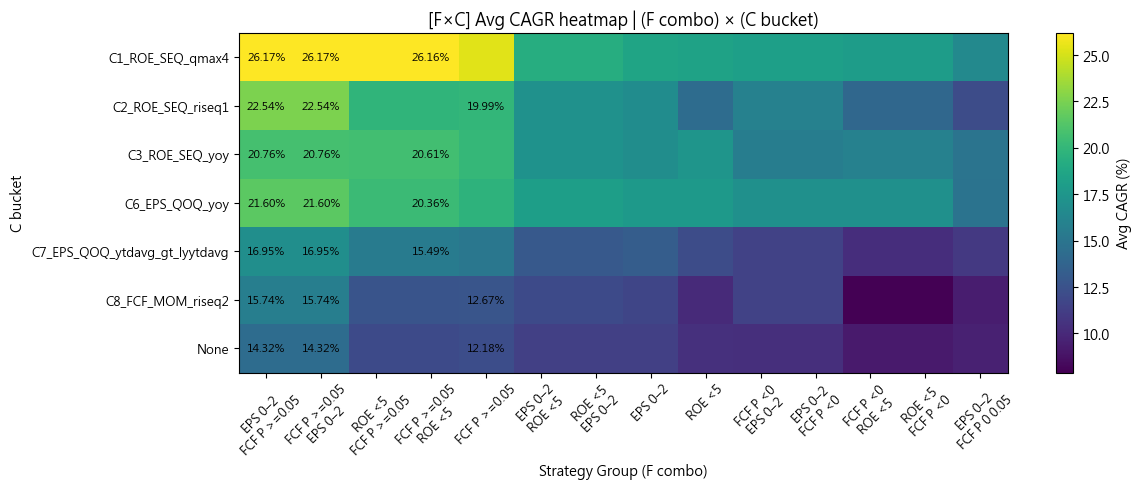

In [37]:
plot_heatmap_nicer(
    pivot_Fcombo_C,
    title="[F×C] Avg CAGR heatmap | (F combo) × (C bucket)",
    top_cols=14,            # 控制欄數
    col_rank_by="mean",     # 以平均 CAGR 排序
    annotate="topk",        # 每列只標 topk
    annotate_topk=3,
    rotate_xticks=45,       # x 軸標籤改 45 度旋轉，避免文字重疊
    tick_fontsize=9,
    ann_fontsize=8,
    fname="FC_heatmap_Fcombo_x_C_mean_CAGR_pretty"
)


### 圖 D.4　固定不同子樹條件之動態因子 CAGR 分布

將分析鎖定於特定子樹，並列比較兩組體質子樹下各動態因子的 CAGR 分布。

這張圖可用來觀察：同一動態因子在兩組子樹下的相對位置是否改變（替換第二層體質因子後，動態因子分布是否移動），藉此判斷動態因子的邊際貢獻是否與所搭配的體質因子有關。子樹固定分析可在指定體質背景下檢驗特定動態因子的敏感度。

Group 1 (ROE_5_10 × EPS_0_2)：14 筆資料，C類別：7
Group 2 (ROE_5_10 × FCF_P=0.05)：0 筆資料，C類別：0
saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\C_compare_2groups_ROE_5_10_vs_ROE_5_10_CAGR.png


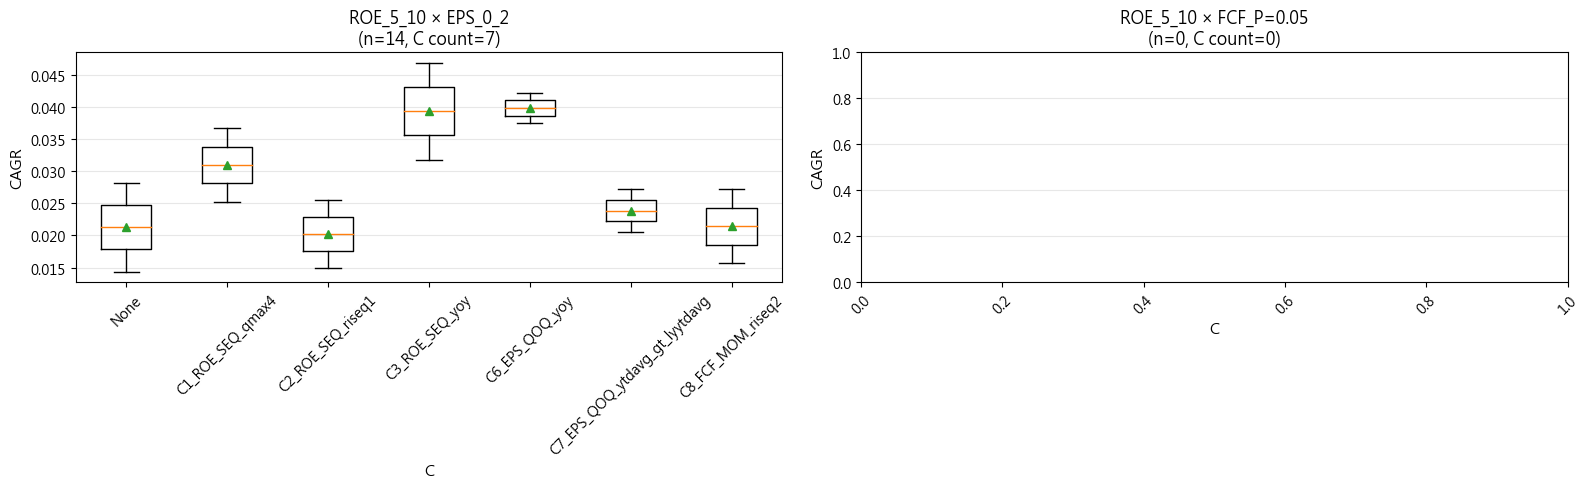

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\C_compare_overlay_2groups_CAGR.png


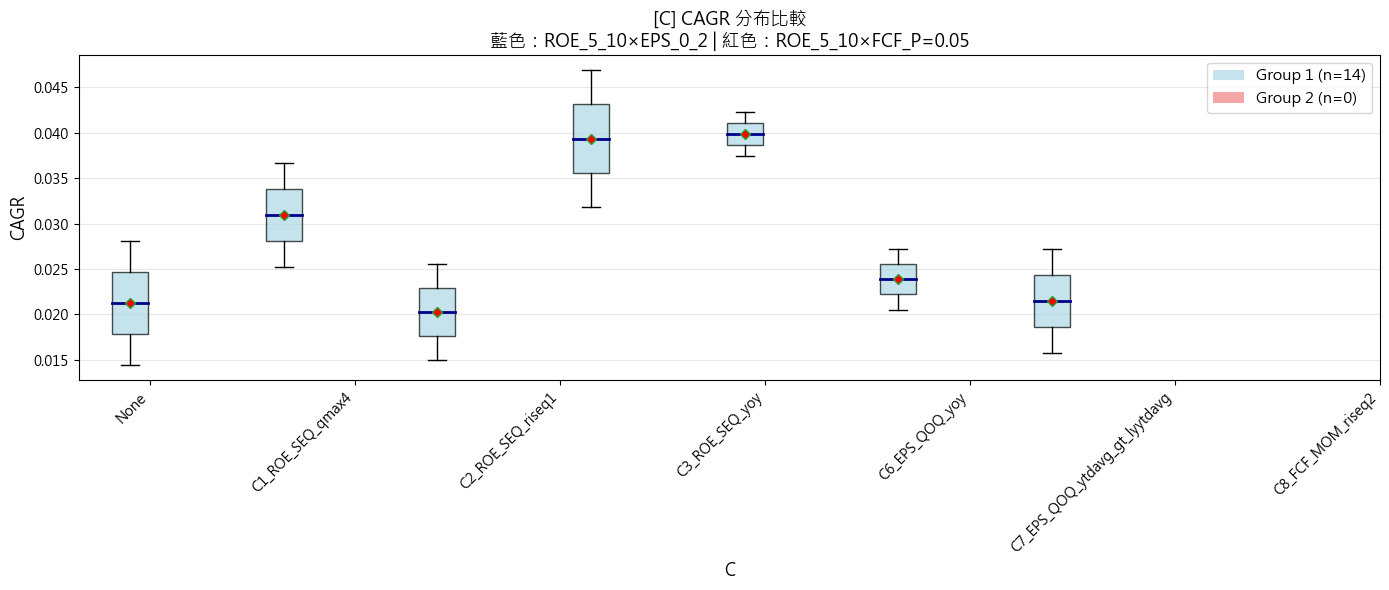

In [38]:
# 在同一張圖上比較兩組 F1 x F2 條件的 C 分布
# ============================================
# 定義第一組條件
group1_f1 = "ROE_5_10"
group1_f2 = "EPS_0_2"

# 定義第二組條件
group2_f1 = "ROE_5_10"
group2_f2 = "FCF_P=0.05"
# ============================================

# 篩選第一組數據
df_group1 = df_scored[
    (df_scored[F1_COL] == group1_f1) & 
    (df_scored[F2_COL] == group1_f2)
].copy()
df_group1['group_label'] = f"{group1_f1} × {group1_f2}"

# 篩選第二組數據
df_group2 = df_scored[
    (df_scored[F1_COL] == group2_f1) & 
    (df_scored[F2_COL] == group2_f2)
].copy()
df_group2['group_label'] = f"{group2_f1} × {group2_f2}"

# 合併兩組數據
df_combined = pd.concat([df_group1, df_group2], ignore_index=True)
df_combined[metric] = _to_num(df_combined[metric])

print(f"Group 1 ({group1_f1} × {group1_f2})：{len(df_group1)} 筆資料，C類別：{df_group1['C'].nunique()}")
print(f"Group 2 ({group2_f1} × {group2_f2})：{len(df_group2)} 筆資料，C類別：{df_group2['C'].nunique()}")

# 自訂排序函數（None優先，然後按照 c1-c8 順序）
def sort_c_values(c_list):
    def c_sort_key(x):
        x_str = str(x)
        if x_str == 'None':
            return (0, 0)  # None 排在最前
        elif x_str.startswith('c') and x_str[1:].isdigit():
            return (1, int(x_str[1:]))  # c 開頭的按數字排序
        else:
            return (2, x_str)  # 其他的放在最後
    return sorted(c_list, key=c_sort_key)

# 繪製並排比較圖（兩個子圖）
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

groups_info = [
    (df_group1, group1_f1, group1_f2, axes[0]),
    (df_group2, group2_f1, group2_f2, axes[1])
]

for df_group, f1_val, f2_val, ax in groups_info:
    # 按 C 分組並計算統計量
    g = df_group.groupby('C')[metric]
    summ = g.agg(['median', 'mean', 'count']).reset_index().sort_values(['median', 'count'], ascending=[False, False])
    
    # 按自訂順序排列 C 值
    c_order = sort_c_values(summ['C'].unique())
    summ['C'] = pd.Categorical(summ['C'], categories=c_order, ordered=True)
    summ = summ.sort_values('C')
    
    # 準備繪圖數據（label 與 data 綁在一起，過濾掉空組，確保長度一致）
    pairs = []
    for c in summ['C']:
        vals = np.asarray(
            df_group.loc[df_group['C'] == c, metric].dropna().values
        ).ravel()
        if vals.size > 0:
            pairs.append((str(c), vals))

    if pairs:
        c_labels = [p[0] for p in pairs]
        data_by_c = [p[1] for p in pairs]
        # matplotlib 3.9+ 已將 labels 改名為 tick_labels
        ax.boxplot(data_by_c, labels=c_labels, showmeans=True)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel('C', fontsize=11)
    ax.set_title(f"{f1_val} × {f2_val}\n(n={len(df_group)}, C count={len(summ)})", fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, f"C_compare_2groups_{group1_f1}_vs_{group2_f1}_{metric}")
plt.show()

# 也可選：在同一圖上疊加兩組的分布（用不同顏色區分）
fig, ax = plt.subplots(figsize=(14, 6))

# 獲取兩組的所有 C 值並按自訂順序排列
all_c_values_unsorted = list(set(list(df_group1['C'].unique()) + list(df_group2['C'].unique())))
all_c_values = sort_c_values(all_c_values_unsorted)

x_pos = 1
for c_val in all_c_values:
    # Group 1
    g1_data = df_group1.loc[df_group1['C'] == c_val, metric].dropna().values
    if len(g1_data) > 0:
        bp1 = ax.boxplot([g1_data], positions=[x_pos], widths=0.35, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='darkblue', linewidth=2),
                         showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
    
    # Group 2
    g2_data = df_group2.loc[df_group2['C'] == c_val, metric].dropna().values
    if len(g2_data) > 0:
        bp2 = ax.boxplot([g2_data], positions=[x_pos + 0.4], widths=0.35, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7),
                         medianprops=dict(color='darkred', linewidth=2),
                         showmeans=True, meanprops=dict(marker='D', markerfacecolor='blue', markersize=5))
    
    x_pos += 1.5

ax.set_ylabel(metric, fontsize=12)
ax.set_xlabel('C', fontsize=12)
ax.set_xticks([i + 0.2 for i in range(1, len(all_c_values) * 2, 2)])
ax.set_xticklabels(all_c_values, rotation=45, ha='right')
ax.set_title(f"[C] {metric} 分布比較\n藍色：{group1_f1}×{group1_f2} | 紅色：{group2_f1}×{group2_f2}", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend([plt.Rectangle((0, 0), 1, 1, fc='lightblue', alpha=0.7),
           plt.Rectangle((0, 0), 1, 1, fc='lightcoral', alpha=0.7)],
          [f"Group 1 (n={len(df_group1)})", f"Group 2 (n={len(df_group2)})"],
          loc='upper right', fontsize=11)

plt.tight_layout()
save_fig(fig, f"C_compare_overlay_2groups_{metric}")
plt.show()

## E. 估值構面

估值構面（V）的設計目的與前兩者不同：體質與動態構面透過正向篩選提升報酬，估值構面則以本益比門檻控制進場估值風險，目的是犧牲部分潛在報酬換取下檔保護。因此評估 V1 的影響時同時納入報酬與風險兩個維度：於同一 F×C 組合下逐對計算 V1 與 V0 的 ΔCAGR 與 ΔMDD（MDD 採負值表示回檔深度，ΔMDD 為正代表回檔變淺、風險下降）。

下列前置 cell 建立每策略一列的 V0/V1 配對表 `pair`（供 ΔCAGR 圖使用）。

V,strategy_key,CAGR_v0,CAGR_v1,delta,abs_delta
0,EPS_<0__FCF_P_<0__C1_ROE_SEQ_qmax4,0.138823,-0.066711,-0.205535,0.205535
1,FCF_P_<0__EPS_<0__C1_ROE_SEQ_qmax4,0.138823,-0.066711,-0.205535,0.205535
2,FCF_P_0_0.05__EPS_<0__C1_ROE_SEQ_qmax4,0.109412,-0.066705,-0.176117,0.176117
3,EPS_<0__FCF_P_0_0.05__C1_ROE_SEQ_qmax4,0.109412,-0.066705,-0.176117,0.176117
4,EPS_<0__FCF_P_>=0.05__C6_EPS_QOQ_yoy,0.173887,0.007392,-0.166495,0.166495
5,FCF_P_>=0.05__EPS_<0__C6_EPS_QOQ_yoy,0.173887,0.007392,-0.166495,0.166495
6,FCF_P_>=0.05__EPS_<0__C3_ROE_SEQ_yoy,0.146134,-0.019522,-0.165656,0.165656
7,EPS_<0__FCF_P_>=0.05__C3_ROE_SEQ_yoy,0.146134,-0.019522,-0.165656,0.165656
8,FCF_P_<0__EPS_<0__C3_ROE_SEQ_yoy,0.134480,-0.030170,-0.164650,0.164650
9,EPS_<0__FCF_P_<0__C3_ROE_SEQ_yoy,0.134480,-0.030170,-0.164650,0.164650


N strategies (paired) = 551
Median ΔCAGR (pp)     = -1.02
IQR ΔCAGR (pp)        = 4.54  (Q1=-3.49, Q3=1.05)
pos_rate (Δ>0)        = 34.8%
Note: Δ = V1 - V0. Positive => V1 better than V0.


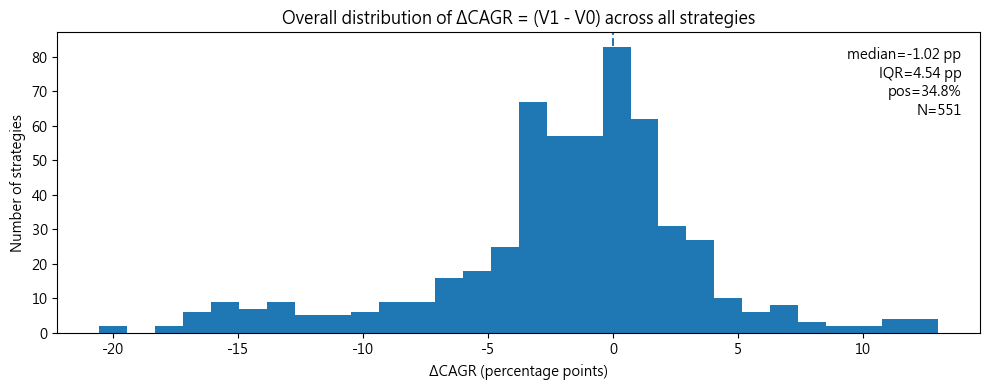

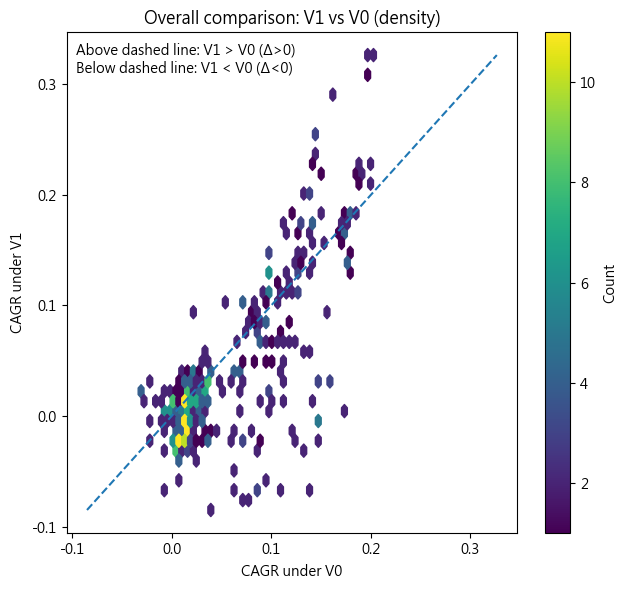

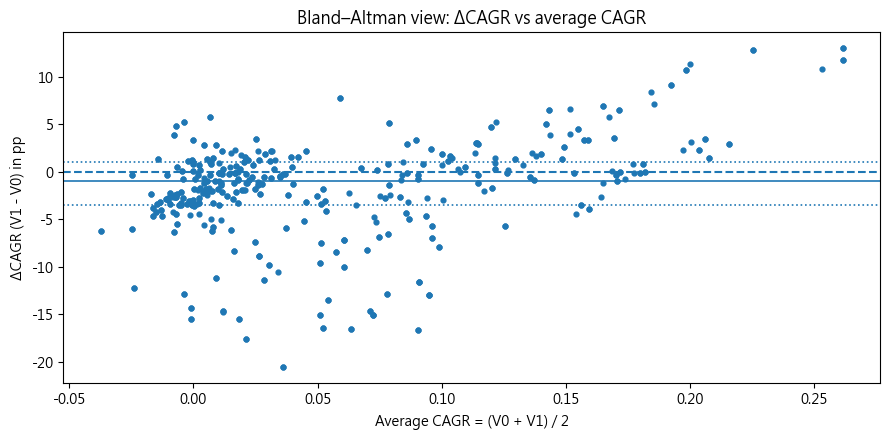

V,strategy_key,CAGR_v0,CAGR_v1,delta,abs_delta
0,EPS_<0__FCF_P_<0__C1_ROE_SEQ_qmax4,0.138823,-0.066711,-0.205535,0.205535
1,FCF_P_<0__EPS_<0__C1_ROE_SEQ_qmax4,0.138823,-0.066711,-0.205535,0.205535
2,FCF_P_0_0.05__EPS_<0__C1_ROE_SEQ_qmax4,0.109412,-0.066705,-0.176117,0.176117
3,EPS_<0__FCF_P_0_0.05__C1_ROE_SEQ_qmax4,0.109412,-0.066705,-0.176117,0.176117
4,EPS_<0__FCF_P_>=0.05__C6_EPS_QOQ_yoy,0.173887,0.007392,-0.166495,0.166495
5,FCF_P_>=0.05__EPS_<0__C6_EPS_QOQ_yoy,0.173887,0.007392,-0.166495,0.166495
6,FCF_P_>=0.05__EPS_<0__C3_ROE_SEQ_yoy,0.146134,-0.019522,-0.165656,0.165656
7,EPS_<0__FCF_P_>=0.05__C3_ROE_SEQ_yoy,0.146134,-0.019522,-0.165656,0.165656
8,FCF_P_<0__EPS_<0__C3_ROE_SEQ_yoy,0.134480,-0.030170,-0.164650,0.164650
9,EPS_<0__FCF_P_<0__C3_ROE_SEQ_yoy,0.134480,-0.030170,-0.164650,0.164650


In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 來源資料表
# =========================
DF = df_scored   # 來源 DataFrame

METRIC = "CAGR"  # 要比較的績效欄位
V_COL  = "V"
V0 = "v0"
V1 = "v1"

# =========================
# 1) 工具：自動找策略欄位 / 建策略key
# =========================
def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def _norm_none(x) -> str:
    if x is None:
        return "None"
    if isinstance(x, float) and np.isnan(x):
        return "None"
    s = str(x).strip()
    if s == "" or s.lower() in ("none", "nan", "null"):
        return "None"
    return s

def _strip_v_suffix(s: str) -> str:
    # 去掉結尾 __v0 或 __v1（也支援 _v0/_v1 或 -v0/-v1）
    return re.sub(r"(__|_|-)(v0|v1)$", "", str(s))

def detect_strategy_key(df: pd.DataFrame, v_col: str, metric: str) -> str:
    """
    回傳可代表策略的欄位名稱；找不到就回傳空字串，之後會改用 (F1,F2,C,...) 組合成 key。
    """
    # 最常見
    preferred = [
        "strategy_norm",
        "strategy_dir",
        "strategy",
        "Strategy",
        "label",
        "name",
    ]
    for col in preferred:
        if col in df.columns:
            return col
    return ""

def build_strategy_key(df: pd.DataFrame, key_col: str, v_col: str, metric: str) -> pd.Series:
    """
    產生策略識別用的 key（不包含 V），用來把 v0/v1 配對。
    """
    if key_col:
        # 用現成欄位，再去掉 v0/v1 後綴
        return df[key_col].astype(str).map(_strip_v_suffix)

    # 沒有策略欄位時：用 F/C 組合拼 key
    # 常見欄位：F1, F2, C
    fc_cols = []
    for c in ["F1", "F2", "F3", "F4", "C"]:
        if c in df.columns:
            fc_cols.append(c)

    # 若連 F1/F2/C 都沒有：退而求其次，用「所有非績效欄位」組合（避免完全無法執行）
    if not fc_cols:
        exclude = {v_col, metric}
        # 再排除一些常見績效欄（若資料中有）
        exclude |= {
            "daily_sharpe", "max_drawdown", "avg_drawdown", "win_ratio",
            "score", "ytd", "mdd", "sharpe"
        }
        fc_cols = [c for c in df.columns if c not in exclude]

    tmp = df[fc_cols].copy()
    for c in fc_cols:
        tmp[c] = tmp[c].map(_norm_none)

    return tmp.astype(str).agg("__".join, axis=1)

# =========================
# 2) 建立「每策略一列」的 v0/v1 配對表
# =========================
def make_pair_table(df: pd.DataFrame, metric: str, v_col: str, v0: str, v1: str) -> pd.DataFrame:
    if v_col not in df.columns:
        raise KeyError(f"Missing column: {v_col}")
    if metric not in df.columns:
        raise KeyError(f"Missing column: {metric}")

    d = df.copy()
    d[metric] = _to_num(d[metric])
    d[v_col] = d[v_col].map(_norm_none)

    # 只保留 v0/v1
    d = d[d[v_col].isin([v0, v1])].copy()

    # 找策略欄位（或自己拼 key）
    key_col = detect_strategy_key(d, v_col=v_col, metric=metric)
    d["strategy_key"] = build_strategy_key(d, key_col=key_col, v_col=v_col, metric=metric)

    # 同策略同 V 若有多筆（例如重複跑或順序不同），先聚合（mean）
    agg = d.groupby(["strategy_key", v_col], as_index=False)[metric].mean()

    pv = agg.pivot(index="strategy_key", columns=v_col, values=metric).copy()
    pv = pv.dropna(subset=[v0, v1], how="any")  # 必須兩邊都有才可比較

    pv["delta"] = pv[v1] - pv[v0]               # Δ = V1 - V0
    pv["abs_delta"] = pv["delta"].abs()
    pv = pv.sort_values("abs_delta", ascending=False)

    pv = pv.reset_index()
    pv.rename(columns={v0: f"{metric}_{v0}", v1: f"{metric}_{v1}"}, inplace=True)
    return pv

pair = make_pair_table(DF, metric=METRIC, v_col=V_COL, v0=V0, v1=V1)
display(pair.head(20))

# =========================
# 3) 整體統計（不分組）
# =========================
def q(x, p):
    return np.nanpercentile(x, p)

delta_pp = pair["delta"].to_numpy() * 100.0  # percentage points
n = np.isfinite(delta_pp).sum()
median = q(delta_pp, 50)
q1 = q(delta_pp, 25)
q3 = q(delta_pp, 75)
iqr = q3 - q1
pos_rate = np.mean(delta_pp > 0)

print(f"N strategies (paired) = {n}")
print(f"Median ΔCAGR (pp)     = {median:.2f}")
print(f"IQR ΔCAGR (pp)        = {iqr:.2f}  (Q1={q1:.2f}, Q3={q3:.2f})")
print(f"pos_rate (Δ>0)        = {pos_rate*100:.1f}%")
print("Note: Δ = V1 - V0. Positive => V1 better than V0.")

# =========================
# 4) 圖 1：Δ 分布（整體幅度 + 穩定度）
# =========================
plt.figure(figsize=(10, 4))
plt.hist(delta_pp, bins=30)
plt.axvline(0, linestyle="--", linewidth=1.5)
plt.title("Overall distribution of ΔCAGR = (V1 - V0) across all strategies")
plt.xlabel("ΔCAGR (percentage points)")
plt.ylabel("Number of strategies")
plt.text(
    0.98, 0.95,
    f"median={median:.2f} pp\nIQR={iqr:.2f} pp\npos={pos_rate*100:.1f}%\nN={n}",
    transform=plt.gca().transAxes,
    ha="right", va="top"
)
plt.tight_layout()
plt.show()

# =========================
# 5) 圖 2：V0 vs V1 密度圖（策略太多時最清楚）
# =========================
v0_vals = pair[f"{METRIC}_{V0}"].to_numpy()
v1_vals = pair[f"{METRIC}_{V1}"].to_numpy()

plt.figure(figsize=(6.5, 6))
hb = plt.hexbin(v0_vals, v1_vals, gridsize=40, mincnt=1)
plt.colorbar(hb, label="Count")
mn = np.nanmin([np.nanmin(v0_vals), np.nanmin(v1_vals)])
mx = np.nanmax([np.nanmax(v0_vals), np.nanmax(v1_vals)])
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)
plt.title("Overall comparison: V1 vs V0 (density)")
plt.xlabel(f"{METRIC} under V0")
plt.ylabel(f"{METRIC} under V1")
plt.text(
    0.02, 0.98,
    "Above dashed line: V1 > V0 (Δ>0)\nBelow dashed line: V1 < V0 (Δ<0)",
    transform=plt.gca().transAxes, ha="left", va="top"
)
plt.tight_layout()
plt.show()

# =========================
# 6) 圖 3（可選）：Bland–Altman（看 Δ 是否與報酬水準相關）
# =========================
avg_vals = (v0_vals + v1_vals) / 2.0

plt.figure(figsize=(9, 4.5))
plt.scatter(avg_vals, delta_pp, s=12)
plt.axhline(0, linestyle="--", linewidth=1.5)
plt.axhline(median, linewidth=1.2)
plt.axhline(q1, linestyle=":", linewidth=1.2)
plt.axhline(q3, linestyle=":", linewidth=1.2)
plt.title("Bland–Altman view: ΔCAGR vs average CAGR")
plt.xlabel(f"Average {METRIC} = (V0 + V1) / 2")
plt.ylabel("ΔCAGR (V1 - V0) in pp")
plt.tight_layout()
plt.show()

# =========================
# 7) （可選）Top K 策略（差異最大）表格輸出（不畫全）
# =========================
TOPK = 20
topk = pair.head(TOPK).copy()
display(topk)

# 也可存成 csv
# topk.to_csv("topk_v_effect.csv", index=False, encoding="utf-8-sig")


### 圖 E.1　V0 與 V1 本益比條件下之 ΔCAGR 分布

以 ΔCAGR = CAGR(V1) − CAGR(V0) 量化估值門檻的邊際影響。

這張圖可用來觀察：ΔCAGR 分布主要落在正值或負值區段（多數策略納入 V1 後 CAGR 是上升或下降），藉此判斷 V1 是否為單向提升報酬的通用濾網，或其效果受「動態構面已先鎖定標的」之影響。

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# =========
# Helper
# =========
def _finite(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def _robust_stats_pp(delta_pp):
    q1, med, q3 = np.percentile(delta_pp, [25, 50, 75])
    iqr = q3 - q1
    pos = float(np.mean(delta_pp > 0))
    n = int(len(delta_pp))
    return q1, med, q3, iqr, pos, n

def _fd_bins(x):
    # Freedman–Diaconis rule with safe fallback
    x = _finite(x)
    n = len(x)
    if n < 2:
        return 10
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    if iqr <= 0:
        return int(np.clip(np.sqrt(n), 12, 45))
    bw = 2 * iqr / (n ** (1/3))
    if bw <= 0:
        return int(np.clip(np.sqrt(n), 12, 45))
    bins = int(np.clip((x.max() - x.min()) / bw, 12, 45))
    return bins

# =========
# 1) Clean histogram
# =========
def plot_delta_hist_clean(
    pair_df,
    delta_col="delta",           # delta = V1 - V0 (in CAGR units)
    title="ΔCAGR distribution across all strategies (Δ = V1 − V0)",
    fname=None,
):
    delta_pp = _finite(pair_df[delta_col].to_numpy() * 100.0)  # pp
    if len(delta_pp) == 0:
        raise ValueError("No valid delta values.")

    q1, med, q3, iqr, pos, n = _robust_stats_pp(delta_pp)
    neg = 1 - pos
    bins = _fd_bins(delta_pp)

    fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)

    ax.hist(delta_pp, bins=bins, edgecolor="white", linewidth=1.0)
    ax.axvline(0, linestyle="--", linewidth=2.2)      # sign boundary
    ax.axvline(med, linewidth=2.0)                    # median
    ax.axvline(q1, linestyle=":", linewidth=1.8)      # Q1
    ax.axvline(q3, linestyle=":", linewidth=1.8)      # Q3

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("ΔCAGR (percentage points)")
    ax.set_ylabel("Number of strategies")
    ax.grid(axis="y", linestyle=":", alpha=0.45)

    # One single stats box (no duplicates)
    box = (
        f"median  = {med:.2f} pp\n"
        f"IQR     = {iqr:.2f} pp\n"
        f"pos(Δ>0)= {pos*100:.1f}%\n"
        f"neg(Δ<0)= {neg*100:.1f}%\n"
        f"N       = {n}"
    )
    ax.text(
        0.98, 0.95, box,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, linewidth=0.8)
    )

    # Optional: a very small note at bottom (won't overlap)
    ax.text(
        0.01, -0.18,
        "Interpretation: Δ>0 → V1 better; Δ<0 → V0 better",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    if fname:
        try:
            save_fig(fig, fname)
        except Exception:
            pass
    plt.show()

# =========
# 2) Clean V1 vs V0 density (hexbin)
# =========
def plot_v0_v1_hexbin_clean(
    pair_df,
    v0_col="CAGR_v0",
    v1_col="CAGR_v1",
    title="V1 vs V0 comparison (density)",
    gridsize=35,
    fname=None,
):
    x = _finite(pair_df[v0_col].to_numpy())
    y = _finite(pair_df[v1_col].to_numpy())
    # need paired finite mask
    X = np.asarray(pair_df[v0_col], dtype=float)
    Y = np.asarray(pair_df[v1_col], dtype=float)
    m = np.isfinite(X) & np.isfinite(Y)
    X, Y = X[m], Y[m]
    if len(X) == 0:
        raise ValueError("No valid (V0, V1) pairs.")

    above = float(np.mean(Y > X))
    below = float(np.mean(Y < X))
    equal = max(0.0, 1.0 - above - below)
    n = int(len(X))

    # same limits + equal aspect so the diagonal is truly 45°
    mn = float(min(X.min(), Y.min()))
    mx = float(max(X.max(), Y.max()))
    pad = (mx - mn) * 0.06 if mx > mn else 0.01
    lo, hi = mn - pad, mx + pad

    fig, ax = plt.subplots(figsize=(6.8, 6.8), constrained_layout=True)

    hb = ax.hexbin(X, Y, gridsize=gridsize, mincnt=1)
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Count")

    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2.2)  # diagonal y=x
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(f"{v0_col}")
    ax.set_ylabel(f"{v1_col}")
    ax.grid(linestyle=":", alpha=0.35)

    # One single stats box
    box = (
        f"Share above diagonal (V1>V0): {above*100:.1f}%\n"
        f"Share below diagonal (V1<V0): {below*100:.1f}%\n"
        f"Share equal: {equal*100:.1f}%\n"
        f"N={n}"
    )
    ax.text(
        0.02, 0.98, box,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, linewidth=0.8)
    )

    # Region labels (small, with white background so they never clash)
    ax.text(
        0.70, 0.86, "V1 better\n(above diagonal)",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, linewidth=0.6)
    )
    ax.text(
        0.70, 0.18, "V0 better\n(below diagonal)",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, linewidth=0.6)
    )

    if fname:
        try:
            save_fig(fig, fname)
        except Exception:
            pass
    plt.show()


C:\Users\dowgojashan\AppData\Local\Temp\ipykernel_7912\4133350704.py:19: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\V_effect_delta_hist_clean.png


d:\研究所\stock_factor_lab-master\stock_factor_lab\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



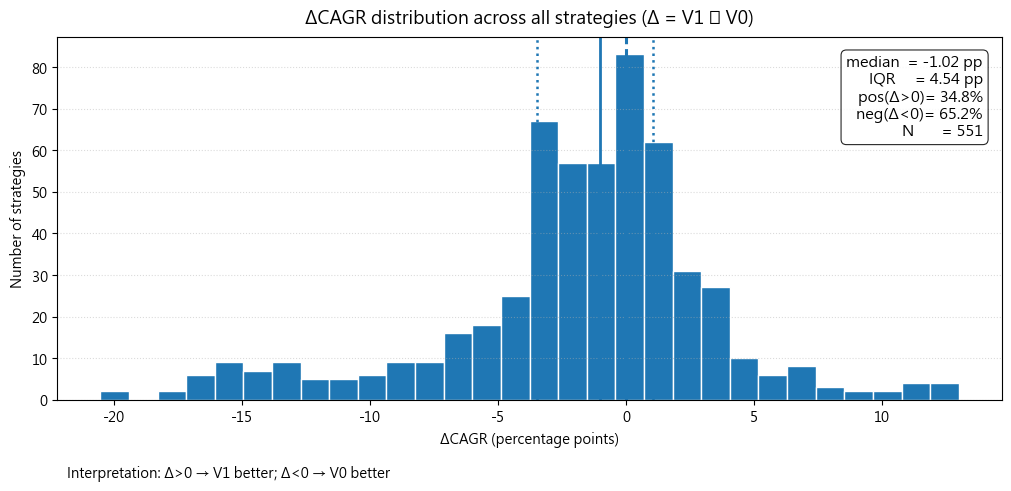

saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\V_effect_v1_vs_v0_hexbin_clean.png


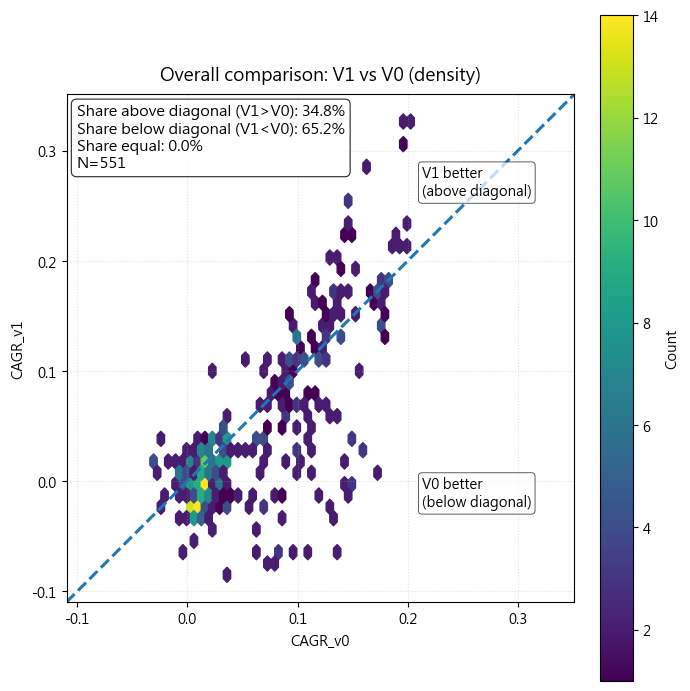

In [41]:
plot_delta_hist_clean(
    pair,
    delta_col="delta",
    title="ΔCAGR distribution across all strategies (Δ = V1 − V0)",
    fname="V_effect_delta_hist_clean"
)

plot_v0_v1_hexbin_clean(
    pair,
    v0_col="CAGR_v0",
    v1_col="CAGR_v1",
    title="Overall comparison: V1 vs V0 (density)",
    gridsize=35,
    fname="V_effect_v1_vs_v0_hexbin_clean"
)


### 圖 E.2　ΔCAGR 與 ΔMDD 聯合分布散布圖

以 ΔMDD 為橫軸、ΔCAGR 為縱軸繪製散布圖，並標示四象限比例（MDD 採負值表示回檔深度，ΔMDD 為正代表回檔變淺、風險下降）。

這張圖可用來觀察：各象限的占比分布，特別是「報酬上升且風險下降」的理想象限與「獲利下降且風險上升」的非預期象限各占多少，藉此判斷獲利下降是否換得對應的風險下降，以及 V1 的適用範圍是否受 F 與 C 條件限制。

C:\Users\dowgojashan\AppData\Local\Temp\ipykernel_7912\4133350704.py:19: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\V_twofig_1_risk_summary_MDD.png


d:\研究所\stock_factor_lab-master\stock_factor_lab\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



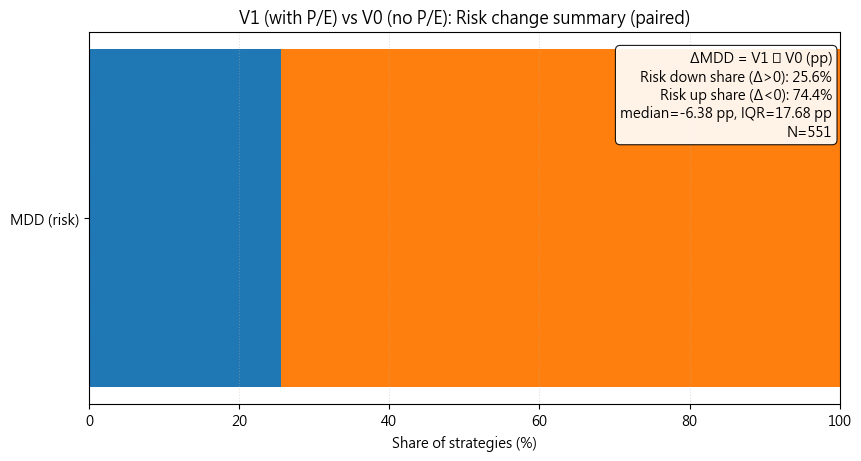

C:\Users\dowgojashan\AppData\Local\Temp\ipykernel_7912\4133350704.py:19: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



saved figure: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\figures_ch4\V_twofig_2_tradeoff_dCAGR_vs_dMDD.png


d:\研究所\stock_factor_lab-master\stock_factor_lab\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 8722 (\N{MINUS SIGN}) missing from current font.



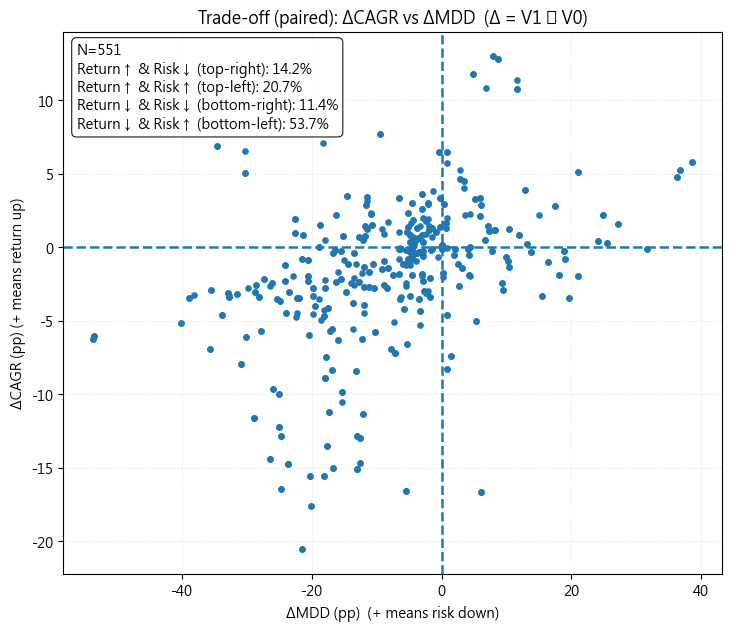

In [42]:
import numpy as np
import matplotlib.pyplot as plt

V_COL = "V"
V0, V1 = "v0", "v1"

# ============ 1) 只做兩個配對表：ΔMDD、ΔCAGR ============
pair_mdd  = make_pair_table(df_scored, metric="max_drawdown", v_col=V_COL, v0=V0, v1=V1)
pair_cagr = make_pair_table(df_scored, metric="CAGR",         v_col=V_COL, v0=V0, v1=V1)

# 只保留有限值
pair_mdd  = pair_mdd[np.isfinite(pair_mdd["delta"].values)].copy()
pair_cagr = pair_cagr[np.isfinite(pair_cagr["delta"].values)].copy()

# 轉成 percentage points（pp）
pair_mdd["delta_pp"]  = pair_mdd["delta"]  * 100.0   # ΔMDD>0 => closer to 0 => risk down
pair_cagr["delta_pp"] = pair_cagr["delta"] * 100.0

# ============ 圖 1：改善比例 + 典型幅度（只看 MDD） ============
vals = pair_mdd["delta_pp"].values
pos = float(np.mean(vals > 0))   # risk down
neg = 1.0 - pos
q1, med, q3 = np.percentile(vals, [25, 50, 75])
iqr = q3 - q1
N = len(vals)

fig, ax = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
# 100% 堆疊
ax.barh(["MDD (risk)"], [pos*100], left=0)
ax.barh(["MDD (risk)"], [neg*100], left=pos*100)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of strategies (%)")
ax.set_title("V1 (with P/E) vs V0 (no P/E): Risk change summary (paired)")

txt = (
    f"ΔMDD = V1 − V0 (pp)\n"
    f"Risk down share (Δ>0): {pos*100:.1f}%\n"
    f"Risk up share (Δ<0): {neg*100:.1f}%\n"
    f"median={med:.2f} pp, IQR={iqr:.2f} pp\n"
    f"N={N}"
)
ax.text(0.99, 0.95, txt, transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, linewidth=0.8))
ax.grid(axis="x", linestyle=":", alpha=0.4)

save_fig(fig, "V_twofig_1_risk_summary_MDD")
plt.show()

# ============ 圖 2：ΔCAGR–ΔMDD 象限取捨圖 ============
both = pair_cagr[["strategy_key", "delta_pp"]].rename(columns={"delta_pp":"dCAGR_pp"}).merge(
    pair_mdd[["strategy_key", "delta_pp"]].rename(columns={"delta_pp":"dMDD_pp"}),
    on="strategy_key", how="inner"
)
x = both["dMDD_pp"].values  # + => risk down
y = both["dCAGR_pp"].values # + => return up

fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
ax.scatter(x, y, s=14)
ax.axvline(0, linestyle="--", linewidth=1.8)
ax.axhline(0, linestyle="--", linewidth=1.8)
ax.set_title("Trade-off (paired): ΔCAGR vs ΔMDD  (Δ = V1 − V0)")
ax.set_xlabel("ΔMDD (pp)  (+ means risk down)")
ax.set_ylabel("ΔCAGR (pp) (+ means return up)")
ax.grid(linestyle=":", alpha=0.35)

# 四象限比例
n = len(both)
q_ru = float(np.mean((x > 0) & (y > 0)))  # return up & risk down
q_lu = float(np.mean((x < 0) & (y > 0)))  # return up & risk up
q_rd = float(np.mean((x > 0) & (y < 0)))  # return down & risk down
q_ld = 1.0 - q_ru - q_lu - q_rd

ax.text(0.02, 0.98,
        f"N={n}\n"
        f"Return↑ & Risk↓ (top-right): {q_ru*100:.1f}%\n"
        f"Return↑ & Risk↑ (top-left): {q_lu*100:.1f}%\n"
        f"Return↓ & Risk↓ (bottom-right): {q_rd*100:.1f}%\n"
        f"Return↓ & Risk↑ (bottom-left): {q_ld*100:.1f}%",
        transform=ax.transAxes, ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, linewidth=0.8))

save_fig(fig, "V_twofig_2_tradeoff_dCAGR_vs_dMDD")
plt.show()


### 圖 E.3 / 圖 E.4　V0 與 V1 於不同體質因子 / 動態因子下之 CAGR 分布

圖 E.3 依體質因子（F1）分組、圖 E.4 依動態因子（C）分組，各自並排比較 V0 與 V1 的 CAGR 分布。

這組圖可用來觀察：V1 的邊際影響是否具條件性——在哪些區間 V1 明顯改變分布、在哪些區間影響不顯著，以及不同體質／動態因子之間 V1 影響幅度的差異，藉此判斷 V1 的適用性需結合何種 F×C 搭配。

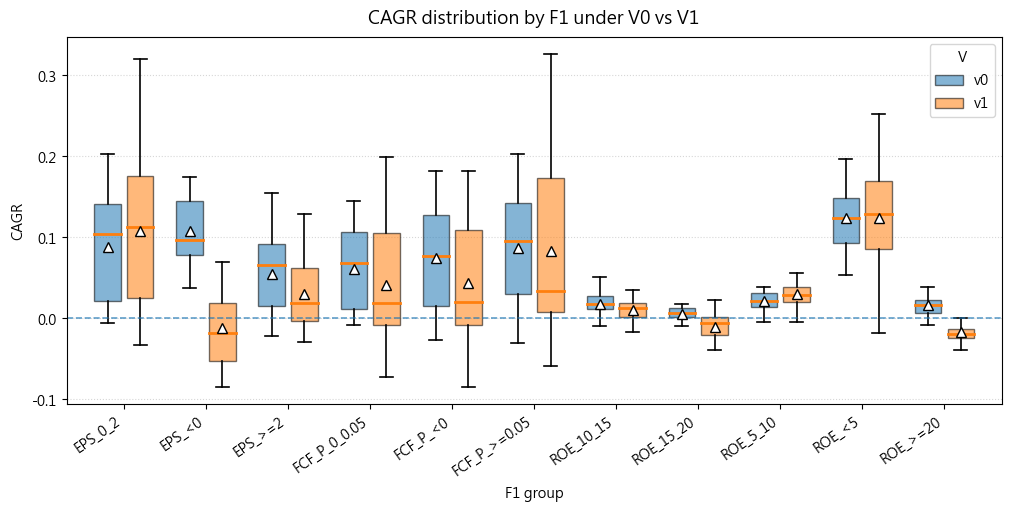

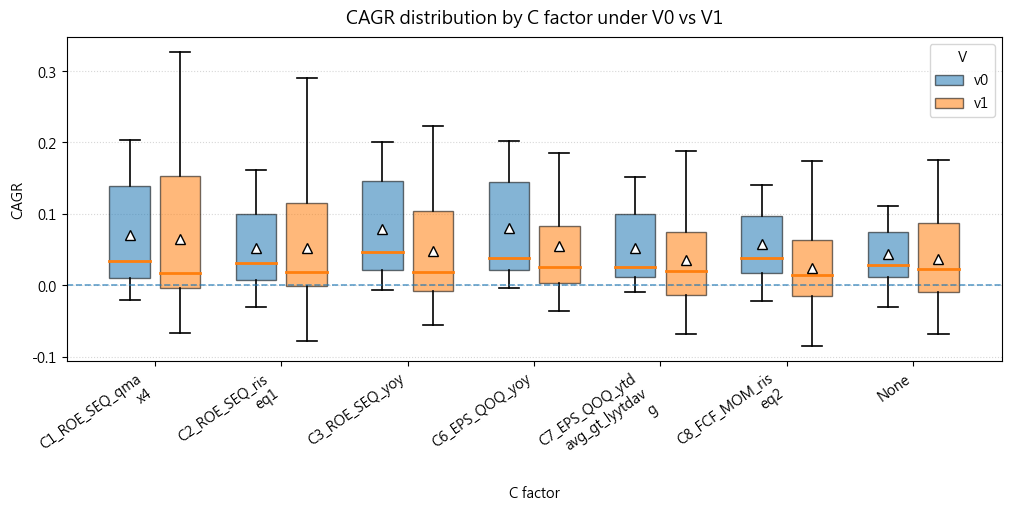

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from textwrap import fill

# =========
# 0) 指定來源總表
# =========
df_in = df_scored  # 來源 DataFrame

# =========
# 1) 通用：並排箱型圖（同一組別內顯示 v0 vs v1）
# =========
def grouped_boxplot_side_by_side(
    df: pd.DataFrame,
    group_col: str,              # "F1" 或 "C"
    value_col: str = "CAGR",      # 要畫的績效指標
    hue_col: str = "V",           # v0/v1
    hue_order=("v0", "v1"),
    group_order=None,            # 可自訂順序；None=自動
    group_label_wrap=14,         # x 標籤自動換行寬度
    min_n_per_box=3,             # 每個箱最少樣本數（太少會失真）
    show_fliers=False,           # 是否顯示離群點
    show_means=True,             # 是否顯示平均值三角形
    title="",
    xlabel="",
    ylabel="CAGR",
):
    # --- basic checks
    for c in [group_col, value_col, hue_col]:
        if c not in df.columns:
            raise KeyError(f"Missing column: {c}")

    d = df.copy()
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d[hue_col] = d[hue_col].astype(str)

    # keep only hue_order
    d = d[d[hue_col].isin(list(hue_order))].copy()
    d = d.dropna(subset=[group_col, value_col])

    # group order
    if group_order is None:
        # 用字串排序，避免混到 None/nan
        group_order = sorted(d[group_col].astype(str).unique().tolist())

    # 準備資料：每個 group 內的 v0/v1 兩個箱
    boxes_data = []
    boxes_pos = []
    boxes_color = []

    # 使用 matplotlib 預設色盤前兩色（不硬指定色碼）
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1"])
    hue_to_color = {hue_order[i]: cycle_colors[i % len(cycle_colors)] for i in range(len(hue_order))}

    # 位置：每個 group 的中心在 i，v0/v1 做左右偏移
    offsets = np.linspace(-0.20, 0.20, num=len(hue_order))
    box_width = 0.32

    # 同時也統計每個箱樣本數，太少就不畫（避免誤導）
    kept_groups = []
    for i, g in enumerate(group_order):
        # group 過濾（用字串比較，兼容原本可能是類別/數值）
        g_mask = (d[group_col].astype(str) == str(g))
        has_any = False

        for j, h in enumerate(hue_order):
            vals = d.loc[g_mask & (d[hue_col] == h), value_col].dropna().values
            if len(vals) < min_n_per_box:
                # 樣本太少：跳過該箱
                continue

            has_any = True
            boxes_data.append(vals)
            boxes_pos.append(i + offsets[j])
            boxes_color.append(hue_to_color[h])

        if has_any:
            kept_groups.append(g)

    if len(boxes_data) == 0:
        raise ValueError("No data to plot after filtering. Check columns / hue values / min_n_per_box.")

    # figure size：group 越多，寬度越大
    fig_w = max(10, len(group_order) * 0.85)
    fig, ax = plt.subplots(figsize=(fig_w, 5), constrained_layout=True)

    bp = ax.boxplot(
        boxes_data,
        positions=boxes_pos,
        widths=box_width,
        patch_artist=True,
        showmeans=show_means,
        showfliers=show_fliers,
        medianprops=dict(linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        meanprops=dict(marker="^", markersize=7, markerfacecolor="white", markeredgecolor="black"),
    )

    # 上色（用預設色盤）
    for patch, fc in zip(bp["boxes"], boxes_color):
        patch.set_facecolor(fc)
        patch.set_alpha(0.55)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)

    # X ticks：以 group 的中心 i 當作刻度
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels([fill(str(g), width=group_label_wrap) for g in group_order], rotation=35, ha="right")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(axis="y", linestyle=":", alpha=0.5)

    # 0 基準線（如果 CAGR 有可能跨 0，這條線可幫助判讀）
    ax.axhline(0, linestyle="--", linewidth=1.2, alpha=0.7)

    # legend
    handles = [Patch(facecolor=hue_to_color[h], edgecolor="black", alpha=0.55, label=h) for h in hue_order]
    ax.legend(handles=handles, title="V", loc="upper right")

    return fig, ax

# =========
# 2) 圖 1：V 對 F 的影響（只以 F1 分類，不看 F2）
# =========
fig, ax = grouped_boxplot_side_by_side(
    df_in,
    group_col="F1",
    value_col="CAGR",
    hue_col="V",
    hue_order=("v0", "v1"),
    title="CAGR distribution by F1 under V0 vs V1",
    xlabel="F1 group",
    ylabel="CAGR",
    min_n_per_box=3,
    show_fliers=False
)
plt.show()

# =========
# 3) 圖 2：V 對 C 的影響（以 C 因子分類）
# =========
fig, ax = grouped_boxplot_side_by_side(
    df_in,
    group_col="C",
    value_col="CAGR",
    hue_col="V",
    hue_order=("v0", "v1"),
    title="CAGR distribution by C factor under V0 vs V1",
    xlabel="C factor",
    ylabel="CAGR",
    min_n_per_box=3,
    show_fliers=False
)
plt.show()


### 圖 E.5　指定子樹條件下之 V0 與 V1 CAGR 分布對照

固定 F[1]=ROE 5–10，並列比較各動態因子下 V0 與 V1 的 CAGR 分布。

這張圖可用來觀察：在此子樹下 V1 對各動態因子的影響方向（是否與整體分析相反、是否出現加分效果），以及搭配哪一類動態因子時 V1 能同時降低風險並維持或提升 CAGR，藉此支持「V1 應依特定 F×C 搭配選擇性套用」的判讀。


=== 分析 F1=ROE_5_10 下的 V0 vs V1 差異 ===

符合 F1=ROE_5_10 的策略數: 83
篩選後的策略數: 83

--- 篩選後數據統計 ---
包含的 V 值: ['v0', 'v1']
包含的 F2 值: ['EPS_0_2', 'EPS_>=2', 'FCF_P_0_0.05', 'FCF_P_<0', 'FCF_P_>=0.05', 'None']
包含的 C 值: ['None', 'C2_ROE_SEQ_riseq1', 'C7_EPS_QOQ_ytdavg_gt_lyytdavg', 'C6_EPS_QOQ_yoy', 'C3_ROE_SEQ_yoy', 'C8_FCF_MOM_riseq2', 'C1_ROE_SEQ_qmax4']

CAGR by V (V0 vs V1):
    count      mean    median       std       min       max
V                                                          
v0     42  0.020871  0.020671  0.019332 -0.027059  0.062606
v1     41  0.030104  0.028124  0.017428 -0.007704  0.097819

--- 平均績效比較 ---
V0 平均: 0.020871
V1 平均: 0.030104
差異 (V1 - V0): 0.009232
相對變化: 44.24%


C:\Users\dowgojashan\AppData\Local\Temp\ipykernel_7912\1769693683.py:87: UserWarning:

The figure layout has changed to tight



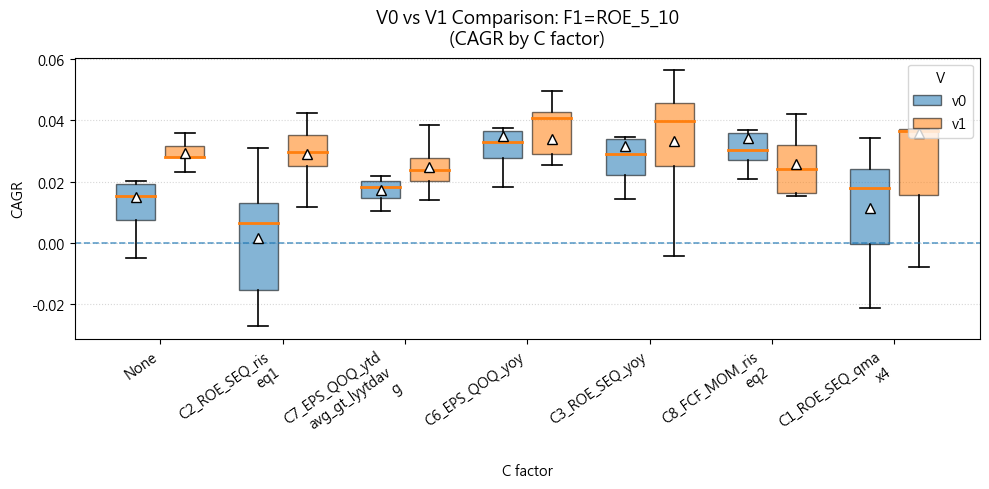


--- 按 C 分組的 V0 vs V1 對比 ---
                            C  V  count     mean   median      std       min      max
                         None v0      6 0.014872 0.015229 0.014555 -0.004916 0.038263
                         None v1      6 0.029267 0.028054 0.004366  0.023227 0.035800
            C2_ROE_SEQ_riseq1 v0      6 0.001523 0.006353 0.022295 -0.027059 0.030934
            C2_ROE_SEQ_riseq1 v1      6 0.029066 0.029768 0.010703  0.011754 0.042488
C7_EPS_QOQ_ytdavg_gt_lyytdavg v0      6 0.017216 0.018400 0.004340  0.010346 0.021686
C7_EPS_QOQ_ytdavg_gt_lyytdavg v1      6 0.024624 0.023844 0.008534  0.013854 0.038486
               C6_EPS_QOQ_yoy v0      6 0.034884 0.032926 0.014587  0.018202 0.061282
               C6_EPS_QOQ_yoy v1      6 0.033931 0.040648 0.016617  0.004142 0.049731
               C3_ROE_SEQ_yoy v0      6 0.031730 0.029108 0.016795  0.014411 0.062606
               C3_ROE_SEQ_yoy v1      6 0.033232 0.039784 0.021802 -0.004270 0.056300
            C8_FCF_MOM_ri

In [44]:
# =========================================================================
# 進階分析：指定 F1，分析 V0 vs V1 差異（取全體）
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from textwrap import fill

# =========
# 1) 指定篩選條件
# =========
TARGET_F1 = "ROE_5_10"    # 指定 F1 條件
METRIC_COL = "CAGR"        # 績效指標

print(f"\n=== 分析 F1={TARGET_F1} 下的 V0 vs V1 差異 ===\n")

# =========
# 2) 篩選符合條件的數據
# =========
df_filtered = df_scored.copy()

# 篩選 F1
mask_f1 = df_filtered["F1"].astype(str) == str(TARGET_F1)
print(f"符合 F1={TARGET_F1} 的策略數: {mask_f1.sum()}")

# 應用 F1 篩選
df_filtered = df_filtered[mask_f1].copy()
print(f"篩選後的策略數: {len(df_filtered)}")

# =========
# 輔助函數：固定 C 值排序（None 先，然後 C1~C8）
# =========
def sort_c_values(c_list):
    """排序 C 值：None 優先，然後 C1~C8"""
    c_order = ["None"] + [f"C{i}" for i in range(1, 9)]
    sorted_c = sorted(c_list, key=lambda x: c_order.index(str(x)) if str(x) in c_order else 999)
    return sorted_c

if len(df_filtered) == 0:
    print("\n⚠️ 警告：沒有符合條件的策略！請檢查 TARGET_F1 的值。")
else:
    # =========
    # 3) 統計摘要
    # =========
    print(f"\n--- 篩選後數據統計 ---")
    print(f"包含的 V 值: {sorted(df_filtered['V'].unique())}")
    print(f"包含的 F2 值: {sorted(df_filtered['F2'].unique())}")
    print(f"包含的 C 值: {sort_c_values(df_filtered['C'].unique())}")
    
    # 轉換 METRIC_COL 為數值
    df_filtered[METRIC_COL] = pd.to_numeric(df_filtered[METRIC_COL], errors="coerce")
    
    # 按 V 分組統計
    v_stats = df_filtered.groupby("V")[METRIC_COL].agg(["count", "mean", "median", "std", "min", "max"])
    print(f"\n{METRIC_COL} by V (V0 vs V1):")
    print(v_stats)
    
    # 計算差異
    v0_mean = df_filtered[df_filtered["V"] == "v0"][METRIC_COL].mean()
    v1_mean = df_filtered[df_filtered["V"] == "v1"][METRIC_COL].mean()
    delta_mean = v1_mean - v0_mean
    delta_pct = (delta_mean / abs(v0_mean) * 100) if v0_mean != 0 else np.nan
    
    print(f"\n--- 平均績效比較 ---")
    print(f"V0 平均: {v0_mean:.6f}")
    print(f"V1 平均: {v1_mean:.6f}")
    print(f"差異 (V1 - V0): {delta_mean:.6f}")
    print(f"相對變化: {delta_pct:.2f}%")
    
    # =========
    # 4) 視覺化：V0 vs V1 並排箱型圖（按 C 分組）
    # =========
    fig, ax = grouped_boxplot_side_by_side(
        df_filtered,
        group_col="C",
        value_col=METRIC_COL,
        hue_col="V",
        hue_order=("v0", "v1"),
        title=f"V0 vs V1 Comparison: F1={TARGET_F1}\n({METRIC_COL} by C factor)",
        xlabel="C factor",
        ylabel=METRIC_COL,
        min_n_per_box=1,  # 取全體，不限制樣本數
        show_fliers=False,
        group_order=sort_c_values(df_filtered["C"].unique())  # 使用固定排序
    )
    plt.tight_layout()
    plt.show()
    
    # =========
    # 5) 詳細對比表：按 C 分組
    # =========
    print(f"\n--- 按 C 分組的 V0 vs V1 對比 ---")
    comparison_rows = []
    for c_val in sort_c_values(df_filtered["C"].unique()):
        c_mask = df_filtered["C"].astype(str) == str(c_val)
        for v_val in ["v0", "v1"]:
            v_mask = df_filtered["V"] == v_val
            subset = df_filtered[c_mask & v_mask][METRIC_COL].dropna()
            if len(subset) > 0:
                comparison_rows.append({
                    "C": c_val,
                    "V": v_val,
                    "count": len(subset),
                    "mean": subset.mean(),
                    "median": subset.median(),
                    "std": subset.std(),
                    "min": subset.min(),
                    "max": subset.max(),
                })
    
    comparison_df = pd.DataFrame(comparison_rows)
    print(comparison_df.to_string(index=False))
    
    # =========
    # 6) 計算 Delta（V1 vs V0）
    # =========
    print(f"\n--- Delta 分析 (V1 - V0 by C) ---")
    delta_rows = []
    for c_val in sort_c_values(df_filtered["C"].unique()):
        c_mask = df_filtered["C"].astype(str) == str(c_val)
        v0_vals = df_filtered[c_mask & (df_filtered["V"] == "v0")][METRIC_COL].dropna().values
        v1_vals = df_filtered[c_mask & (df_filtered["V"] == "v1")][METRIC_COL].dropna().values
        
        if len(v0_vals) > 0 and len(v1_vals) > 0:
            delta_vals = []
            for v0 in v0_vals:
                for v1 in v1_vals:
                    delta_vals.append(v1 - v0)
            delta_vals = np.array(delta_vals)
            
            delta_rows.append({
                "C": c_val,
                "delta_mean": delta_vals.mean(),
                "delta_median": np.median(delta_vals),
                "delta_std": delta_vals.std(),
                "positive_rate": (delta_vals > 0).sum() / len(delta_vals),
                "n_comparisons": len(delta_vals),
            })
    
    delta_comparison_df = pd.DataFrame(delta_rows)
    print(delta_comparison_df.to_string(index=False))
    
    print(f"\n✓ 分析完成！")

## F. 附錄：基礎分析輸出

以下為計算用函式與摘要表，提供前述分析的背景參考：C 構面的邊際貢獻（ΔC）、V 構面的邊際貢獻（ΔV）、因子區間（bucket）摘要，以及依穩健性產生的 C 推薦／避免清單。這些 cell 不產生編號圖，主要輸出摘要表與 CSV。

In [45]:
def compute_delta_C(df_in: pd.DataFrame, metric: str = "CAGR", v_value: str = "v0") -> pd.DataFrame:
    """
    delta_C(v_value) = metric(F1,F2,C,V=v_value) - metric(F1,F2,C=None,V=v_value)

    用 merge 明確對齊 baseline，且「固定 V 版本」避免混入 v0/v1 的差異。
    """
    df0 = df_in.copy()
    df0[metric] = pd.to_numeric(df0[metric], errors="coerce")

    # baseline: (F1,F2,C=None,V=v_value)
    base = (
        df0[(df0["C"] == "None") & (df0["V"] == v_value)]
        .groupby(["F1", "F2"], dropna=False)[metric]
        .mean()
        .rename("baseline")
        .reset_index()
    )

    # with C: (F1,F2,C!=None,V=v_value)
    cur = (
        df0[(df0["C"] != "None") & (df0["V"] == v_value)]
        .groupby(["F1", "F2", "C"], dropna=False)[metric]
        .mean()
        .rename("with_C")
        .reset_index()
    )

    out = cur.merge(base, on=["F1", "F2"], how="left")
    out["delta"] = out["with_C"] - out["baseline"]
    out["has_baseline"] = out["baseline"].notna()
    out["V"] = v_value
    return out

def summarize_delta(delta_df: pd.DataFrame) -> pd.DataFrame:
    g = delta_df.groupby("C")["delta"]
    out = pd.DataFrame({
        "mean": g.mean(),
        "median": g.median(),
        "iqr": g.quantile(0.75) - g.quantile(0.25),
        "pos_rate": g.apply(lambda s: (s > 0).mean()),
        "n": g.size(),
    }).sort_values(["pos_rate","mean"], ascending=False)
    return out.reset_index()

# 針對每個 V 版本各做一次 ΔC
deltaC_list = []
summaryC_list = []

for v in ANALYZE_V_VALUES:
    d = compute_delta_C(df_scored, metric=metric, v_value=v)
    deltaC_list.append(d)

    s = summarize_delta(d).assign(V=v)
    summaryC_list.append(s)

    # 各自存檔
    s.to_csv(OUT_DIR / f"deltaC_summary_{metric}_{v}.csv", index=False, encoding="utf-8-sig")
    print("saved:", OUT_DIR / f"deltaC_summary_{metric}_{v}.csv")

deltaC_all = pd.concat(deltaC_list, ignore_index=True) if deltaC_list else pd.DataFrame()
summaryC_all = pd.concat(summaryC_list, ignore_index=True) if summaryC_list else pd.DataFrame()

print("deltaC_all rows:", len(deltaC_all))
display(deltaC_all.head())

print("summaryC_all:")
display(summaryC_all.sort_values(["V","pos_rate","mean"], ascending=[True, False, False]))

summaryC_all.to_csv(OUT_DIR / f"deltaC_summary_{metric}_ALLV.csv", index=False, encoding="utf-8-sig")
print("saved:", OUT_DIR / f"deltaC_summary_{metric}_ALLV.csv")

# 後續視覺化預設用 PLOT_V
deltaC = deltaC_all[deltaC_all["V"] == PLOT_V].copy()
summaryC = summaryC_all[summaryC_all["V"] == PLOT_V].copy()

print(f"plotting V = {PLOT_V} | deltaC rows:", len(deltaC))

saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\deltaC_summary_CAGR_v0.csv
saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\deltaC_summary_CAGR_v1.csv
deltaC_all rows: 958


,F1,F2,C,with_C,baseline,delta,has_baseline,V
0,EPS_0_2,FCF_P_0_0.05,C1_ROE_SEQ_qmax4,0.130827,0.083841,0.046986,True,v0
1,EPS_0_2,FCF_P_0_0.05,C2_ROE_SEQ_riseq1,0.119794,0.083841,0.035953,True,v0
2,EPS_0_2,FCF_P_0_0.05,C3_ROE_SEQ_yoy,0.136062,0.083841,0.052221,True,v0
3,EPS_0_2,FCF_P_0_0.05,C6_EPS_QOQ_yoy,0.141623,0.083841,0.057782,True,v0
4,EPS_0_2,FCF_P_0_0.05,C7_EPS_QOQ_ytdavg_gt_lyytdavg,0.107033,0.083841,0.023192,True,v0


summaryC_all:


,C,mean,median,iqr,pos_rate,n,V
0,C6_EPS_QOQ_yoy,0.037192,0.023019,0.072890,0.925926,81,v0
1,C3_ROE_SEQ_yoy,0.035273,0.023546,0.063703,0.876543,81,v0
2,C8_FCF_MOM_riseq2,0.015299,0.018651,0.029236,0.802469,81,v0
3,C1_ROE_SEQ_qmax4,0.027266,0.010843,0.051307,0.728395,81,v0
4,C2_ROE_SEQ_riseq1,0.009253,0.009108,0.033729,0.654321,81,v0
5,C7_EPS_QOQ_ytdavg_gt_lyytdavg,0.009685,0.006124,0.028100,0.629630,81,v0
6,C6_EPS_QOQ_yoy,0.017109,0.007014,0.048763,0.721519,79,v1
7,C3_ROE_SEQ_yoy,0.011436,0.006480,0.029738,0.696203,79,v1
8,C1_ROE_SEQ_qmax4,0.028026,0.001853,0.074495,0.571429,77,v1
9,C2_ROE_SEQ_riseq1,0.014422,0.005227,0.026541,0.556962,79,v1


saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\deltaC_summary_CAGR_ALLV.csv
plotting V = v0 | deltaC rows: 486


In [46]:
def compute_delta_V(
    df_in: pd.DataFrame,
    metric: str = "CAGR",
    baseline_v: str = "v0",
    target_v: str | None = "v1",
) -> pd.DataFrame:
    """
    目的：量化「有無 PE 入場控制」的影響。

    - baseline_v='v0'（未使用 PE 入場控制）
    - target_v='v1'（使用 PE 入場控制）

    定義：
    ΔV = metric(F1,F2,C,V=target_v) - metric(F1,F2,C,V=baseline_v)

    若 target_v 不存在（例如資料不是 v0/v1），就退回成：
    ΔV = metric(F1,F2,C,V!=baseline_v) - metric(F1,F2,C,V=baseline_v)
    """
    df0 = df_in.copy()
    df0[metric] = pd.to_numeric(df0[metric], errors="coerce")

    base = (
        df0[(df0["V"] == baseline_v)]
        .groupby(["F1", "F2", "C"], dropna=False)[metric]
        .mean()
        .rename("baseline")
        .reset_index()
    )

    if target_v is not None and target_v in df0["V"].astype(str).unique():
        cur = (
            df0[(df0["V"] == target_v)]
            .groupby(["F1", "F2", "C"], dropna=False)[metric]
            .mean()
            .rename("with_V")
            .reset_index()
        )
        out = cur.merge(base, on=["F1", "F2", "C"], how="left")
        out["V_compare"] = f"{target_v}_minus_{baseline_v}"
    else:
        cur = (
            df0[(df0["V"] != baseline_v)]
            .groupby(["F1", "F2", "C", "V"], dropna=False)[metric]
            .mean()
            .rename("with_V")
            .reset_index()
        )
        out = cur.merge(base, on=["F1", "F2", "C"], how="left")
        out["V_compare"] = out["V"].astype(str) + "_minus_" + str(baseline_v)

    out["delta"] = out["with_V"] - out["baseline"]
    out["has_baseline"] = out["baseline"].notna()
    out["baseline_V"] = baseline_v
    return out

# baseline 優先用 v0（若不存在則用 BASELINE_V）
baseline_v = "v0" if "v0" in V_VALUES else BASELINE_V
target_v = "v1" if "v1" in V_VALUES and baseline_v == "v0" else None

deltaV = compute_delta_V(df_scored, metric=metric, baseline_v=baseline_v, target_v=target_v)
print("deltaV rows:", len(deltaV))
display(deltaV.head())

if len(deltaV) == 0:
    print("目前沒有可用的 V 版本差異資料（可能只有單一 V）。")
else:
    # 只在 v0/v1 情境下：比較固定為 v1 - v0
    if target_v is not None:
        summaryV = deltaV["delta"].agg(
            mean="mean",
            median="median",
            iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
        )
        pos_rate = (deltaV["delta"] > 0).mean()
        n = len(deltaV)

        summaryV_df = pd.DataFrame([{
            "V_compare": f"{target_v}_minus_{baseline_v}",
            "mean": summaryV["mean"],
            "median": summaryV["median"],
            "iqr": summaryV["iqr"],
            "pos_rate": pos_rate,
            "n": n,
        }])

        display(summaryV_df)

        detail_path = OUT_DIR / f"deltaV_detail_{metric}_{target_v}_minus_{baseline_v}.csv"
        summ_path   = OUT_DIR / f"deltaV_summary_{metric}_{target_v}_minus_{baseline_v}.csv"
        deltaV.to_csv(detail_path, index=False, encoding="utf-8-sig")
        summaryV_df.to_csv(summ_path, index=False, encoding="utf-8-sig")
        print("saved:", detail_path)
        print("saved:", summ_path)

    else:
        # fallback：資料不是 v0/v1 時，改用 by V 的彙總
        summaryV = deltaV.groupby("V")["delta"].agg(
            mean="mean",
            median="median",
            iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
            pos_rate=lambda s: (s>0).mean(),
            n="size",
        ).sort_values(["pos_rate","mean"], ascending=False).reset_index()

        display(summaryV)

        detail_path = OUT_DIR / f"deltaV_detail_{metric}_baseline_{baseline_v}.csv"
        summ_path   = OUT_DIR / f"deltaV_summary_{metric}_baseline_{baseline_v}.csv"
        deltaV.to_csv(detail_path, index=False, encoding="utf-8-sig")
        summaryV.to_csv(summ_path, index=False, encoding="utf-8-sig")
        print("saved:", detail_path)
        print("saved:", summ_path)


deltaV rows: 551


,F1,F2,C,with_V,baseline,V_compare,delta,has_baseline,baseline_V
0,EPS_0_2,FCF_P_0_0.05,C1_ROE_SEQ_qmax4,0.199542,0.130827,v1_minus_v0,0.068715,True,v0
1,EPS_0_2,FCF_P_0_0.05,C2_ROE_SEQ_riseq1,0.123094,0.119794,v1_minus_v0,0.003300,True,v0
2,EPS_0_2,FCF_P_0_0.05,C3_ROE_SEQ_yoy,0.162227,0.136062,v1_minus_v0,0.026164,True,v0
3,EPS_0_2,FCF_P_0_0.05,C6_EPS_QOQ_yoy,0.155055,0.141623,v1_minus_v0,0.013432,True,v0
4,EPS_0_2,FCF_P_0_0.05,C7_EPS_QOQ_ytdavg_gt_lyytdavg,0.112066,0.107033,v1_minus_v0,0.005033,True,v0


,V_compare,mean,median,iqr,pos_rate,n
0,v1_minus_v0,-0.018525,-0.010242,0.045351,0.348457,551


saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\deltaV_detail_CAGR_v1_minus_v0.csv
saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\deltaV_summary_CAGR_v1_minus_v0.csv


In [47]:
def split_factor_prefix(bucket: str) -> str:
    if bucket is None:
        return "None"
    m = re.search(r"(>=|<=|=|>|<)", bucket)
    if m:
        return bucket[:m.start()]
    if "_between_" in bucket:
        return bucket.split("_between_")[0]
    return bucket

def bucket_summary(df_in: pd.DataFrame, level: str, metric: str) -> pd.DataFrame:
    tmp = df_in.copy()
    tmp["factor_prefix"] = tmp[level].astype(str).apply(split_factor_prefix)
    agg = tmp.groupby([level, "factor_prefix"])[metric].agg(["mean","median","std","count"]).reset_index()
    return agg.sort_values(["mean","count"], ascending=[False, False])

bF1 = bucket_summary(df_scored, "F1", metric)
bF2 = bucket_summary(df_scored, "F2", metric)

display(bF1.head(30))
display(bF2.head(30))

bF1.to_csv(OUT_DIR / f"bucket_F1_{metric}.csv", index=False, encoding="utf-8-sig")
bF2.to_csv(OUT_DIR / f"bucket_F2_{metric}.csv", index=False, encoding="utf-8-sig")
print("saved:",
      OUT_DIR / f"bucket_F1_{metric}.csv",
      OUT_DIR / f"bucket_F2_{metric}.csv")

,F1,factor_prefix,mean,median,std,count
9,ROE_<5,ROE_,0.123439,0.125116,0.059238,98
0,EPS_0_2,EPS_0_2,0.096887,0.111455,0.078203,119
5,FCF_P_>=0.05,FCF_P_,0.084665,0.061130,0.087547,126
4,FCF_P_<0,FCF_P_,0.058786,0.035883,0.071130,126
3,FCF_P_0_0.05,FCF_P_0_0.05,0.050860,0.034494,0.060799,126
1,EPS_<0,EPS_,0.048102,0.061132,0.074177,70
2,EPS_>=2,EPS_,0.042712,0.032696,0.044016,125
8,ROE_5_10,ROE_5_10,0.025432,0.026416,0.018884,83
6,ROE_10_15,ROE_10_15,0.014252,0.015592,0.014483,84
10,ROE_>=20,ROE_,0.000662,0.003556,0.020734,77


,F2,factor_prefix,mean,median,std,count
10,ROE_<5,ROE_,0.120071,0.120095,0.061462,84
0,EPS_0_2,EPS_0_2,0.089577,0.098728,0.079586,105
6,None,None,0.080980,0.084182,0.071123,154
5,FCF_P_>=0.05,FCF_P_,0.072911,0.037940,0.083644,112
4,FCF_P_<0,FCF_P_,0.050512,0.023583,0.070100,112
1,EPS_<0,EPS_,0.046178,0.061132,0.075846,56
3,FCF_P_0_0.05,FCF_P_0_0.05,0.043099,0.023389,0.059041,112
2,EPS_>=2,EPS_,0.038367,0.018880,0.044386,111
9,ROE_5_10,ROE_5_10,0.025877,0.026416,0.020046,69
7,ROE_10_15,ROE_10_15,0.013788,0.015592,0.015299,70


saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\bucket_F1_CAGR.csv D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\bucket_F2_CAGR.csv


In [48]:
def recommend_C(summaryC: pd.DataFrame, pos_rate_min: float = 0.6, top_k: int = 10):
    s = summaryC.copy()
    good = s[(s["pos_rate"] >= pos_rate_min)].sort_values(["pos_rate","mean"], ascending=False).head(top_k)
    bad  = s[(s["pos_rate"] < pos_rate_min)].sort_values(["pos_rate","mean"], ascending=True).head(top_k)
    return good, bad

goodC, badC = recommend_C(summaryC, pos_rate_min=0.6, top_k=10)
print("=== 推薦 C（穩健）===")
display(goodC)
print("=== 需小心 C（不穩健）===")
display(badC)

goodC.to_csv(OUT_DIR / f"recommend_C_{metric}.csv", index=False, encoding="utf-8-sig")
badC.to_csv(OUT_DIR / f"avoid_C_{metric}.csv", index=False, encoding="utf-8-sig")
print("saved:", OUT_DIR / f"recommend_C_{metric}.csv", OUT_DIR / f"avoid_C_{metric}.csv")

=== 推薦 C（穩健）===


,C,mean,median,iqr,pos_rate,n,V
0,C6_EPS_QOQ_yoy,0.037192,0.023019,0.072890,0.925926,81,v0
1,C3_ROE_SEQ_yoy,0.035273,0.023546,0.063703,0.876543,81,v0
2,C8_FCF_MOM_riseq2,0.015299,0.018651,0.029236,0.802469,81,v0
3,C1_ROE_SEQ_qmax4,0.027266,0.010843,0.051307,0.728395,81,v0
4,C2_ROE_SEQ_riseq1,0.009253,0.009108,0.033729,0.654321,81,v0
5,C7_EPS_QOQ_ytdavg_gt_lyytdavg,0.009685,0.006124,0.028100,0.629630,81,v0


=== 需小心 C（不穩健）===


,C,mean,median,iqr,pos_rate,n,V


saved: D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\recommend_C_CAGR.csv D:\研究所\stock_factor_lab-master\stock_factor_lab\_analysis_outputs\avoid_C_CAGR.csv
